# Descriptive Analytics Exploration

## IGDB Game Discovery and RAG Recommendation System

This notebook implements the descriptive analytics pillar from `docs/descriptive_analytics_pillar_plan.md`.

Main question: **What does the game catalog look like?**

The goal is to summarize catalog size, composition, platform coverage, release timing, ratings, company representation, metadata completeness, and data-quality readiness. This notebook intentionally uses the normalized SQLite database, not the predictive-layer feature outputs.

## Current Sample Caveat

The current descriptive results represent the project's extracted IGDB sample, not the full IGDB catalog. The current sample size comes from `GAME_LIMIT = 500` in `src/fetch_IGDB.py`. The extraction also requires `total_rating_count > 50`, requires `summary != null`, and sorts by `total_rating_count desc`. Treat all charts as summaries of this project sample, not as market-wide statements about all IGDB games.

In [1]:
from pathlib import Path
import sqlite3

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

pd.set_option('display.max_columns', 80)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda value: f'{value:,.2f}')

ROOT_DIR = Path.cwd()
if ROOT_DIR.name.lower() == 'notebooks':
    ROOT_DIR = ROOT_DIR.parent

DB_PATH = ROOT_DIR / 'data' / 'database' / 'igdb_games.db'
OUTPUT_DIR = ROOT_DIR / 'data' / 'analytics' / 'descriptive'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

if not DB_PATH.exists():
    raise FileNotFoundError(f'Database not found: {DB_PATH}')

conn = sqlite3.connect(DB_PATH)

print(f'Project root: {ROOT_DIR}')
print(f'Database: {DB_PATH}')
print(f'Output directory: {OUTPUT_DIR}')

Project root: c:\Users\calvi\Data Science\Community_Project
Database: c:\Users\calvi\Data Science\Community_Project\data\database\igdb_games.db
Output directory: c:\Users\calvi\Data Science\Community_Project\data\analytics\descriptive


In [2]:
def run_query(sql, params=None):
    return pd.read_sql_query(sql, conn, params=params or {})


def display_section(title, text=None):
    body = f'## {title}'
    if text:
        body += f'\n\n{text}'
    display(Markdown(body))


def add_percent(df, numerator_col, denominator_col='total_games', output_col='pct_of_games'):
    result = df.copy()
    result[output_col] = (100 * result[numerator_col] / result[denominator_col]).round(2)
    return result


def plot_barh(df, label_col, value_col, title, top_n=15, color='#4C78A8'):
    data = df.head(top_n).copy()
    if data.empty:
        print(f'No data to plot: {title}')
        return
    data = data.sort_values(value_col, ascending=True)
    fig_height = max(4, 0.35 * len(data))
    ax = data.plot.barh(x=label_col, y=value_col, figsize=(9, fig_height), legend=False, color=color)
    ax.set_title(title)
    ax.set_xlabel(value_col.replace('_', ' ').title())
    ax.set_ylabel('')
    ax.grid(axis='x', alpha=0.25)
    plt.tight_layout()
    plt.show()


def plot_bar(df, label_col, value_col, title, color='#59A14F', rotation=45):
    if df.empty:
        print(f'No data to plot: {title}')
        return
    ax = df.plot.bar(x=label_col, y=value_col, figsize=(10, 5), legend=False, color=color)
    ax.set_title(title)
    ax.set_xlabel('')
    ax.set_ylabel(value_col.replace('_', ' ').title())
    ax.tick_params(axis='x', rotation=rotation)
    ax.grid(axis='y', alpha=0.25)
    plt.tight_layout()
    plt.show()


tables_to_export = {}

# 1. Database Sanity Check

This section confirms that the notebook is connected to the expected SQLite database and summarizes available tables before analysis.

In [3]:
tables = run_query('''
SELECT
    type,
    name
FROM sqlite_master
WHERE type IN ('table', 'view')
ORDER BY type, name;
''')

row_counts = []
for table_name in tables.loc[tables['type'] == 'table', 'name']:
    count_value = run_query(f'SELECT COUNT(*) AS row_count FROM {table_name}').iloc[0, 0]
    row_counts.append({'table_name': table_name, 'row_count': int(count_value)})

row_counts_df = pd.DataFrame(row_counts).sort_values('table_name').reset_index(drop=True)
tables_to_export['database_table_row_counts'] = row_counts_df

display(row_counts_df)

,table_name,row_count
0,companies,1968
1,covers,2994
2,date_formats,8
3,external_game_sources,22
4,external_games,10517
5,game_genres,6476
6,game_keywords,76609
7,game_modes,6
8,game_modes_bridge,5183
9,game_platforms,8212


In [4]:
integrity_check = run_query('PRAGMA integrity_check;')
foreign_key_check = run_query('PRAGMA foreign_key_check;')

database_status = pd.DataFrame([
    {
        'check_name': 'SQLite integrity check',
        'result': str(integrity_check.iloc[0, 0]),
        'failing_rows': 0 if str(integrity_check.iloc[0, 0]).lower() == 'ok' else 1,
    },
    {
        'check_name': 'Foreign key check',
        'result': 'no failures' if foreign_key_check.empty else 'failures found',
        'failing_rows': len(foreign_key_check),
    },
])

tables_to_export['database_status'] = database_status
display(database_status)
if not foreign_key_check.empty:
    display(foreign_key_check)

,check_name,result,failing_rows
0,SQLite integrity check,ok,0
1,Foreign key check,no failures,0


# 2. Dataset Snapshot

This section gives the audience a quick catalog-level summary: size, represented dimensions, and basic coverage.

In [5]:
kpi_snapshot = run_query('''
WITH total AS (
    SELECT COUNT(DISTINCT game_id) AS total_games
    FROM games
)
SELECT 'Total Games' AS kpi,
       COUNT(DISTINCT game_id) AS value,
       NULL AS pct_of_games,
       'Unique games in games table' AS note
FROM games

UNION ALL
SELECT 'Total Platforms Represented',
       COUNT(DISTINCT platform_id),
       NULL,
       'Distinct platforms linked through game_platforms'
FROM game_platforms

UNION ALL
SELECT 'Total Genres Represented',
       COUNT(DISTINCT genre_id),
       NULL,
       'Distinct genres linked through game_genres'
FROM game_genres

UNION ALL
SELECT 'Total Themes Represented',
       COUNT(DISTINCT theme_id),
       NULL,
       'Distinct themes linked through game_themes'
FROM game_themes

UNION ALL
SELECT 'Total Keywords Represented',
       COUNT(DISTINCT keyword_id),
       NULL,
       'Distinct keywords linked through game_keywords'
FROM game_keywords

UNION ALL
SELECT 'Total Companies Represented',
       COUNT(DISTINCT company_id),
       NULL,
       'Distinct companies linked through involved_companies'
FROM involved_companies

UNION ALL
SELECT 'Games With Total Rating',
       COUNT(DISTINCT CASE WHEN total_rating IS NOT NULL THEN game_id END),
       ROUND(100.0 * COUNT(DISTINCT CASE WHEN total_rating IS NOT NULL THEN game_id END) / (SELECT total_games FROM total), 2),
       'Coverage for rating distribution and rating-band charts'
FROM games

UNION ALL
SELECT 'Games With Total Rating Count',
       COUNT(DISTINCT CASE WHEN total_rating_count IS NOT NULL THEN game_id END),
       ROUND(100.0 * COUNT(DISTINCT CASE WHEN total_rating_count IS NOT NULL THEN game_id END) / (SELECT total_games FROM total), 2),
       'Coverage for rating confidence and visibility charts'
FROM games

UNION ALL
SELECT 'Games With Summaries',
       COUNT(DISTINCT CASE WHEN summary IS NOT NULL AND TRIM(summary) <> '' THEN game_id END),
       ROUND(100.0 * COUNT(DISTINCT CASE WHEN summary IS NOT NULL AND TRIM(summary) <> '' THEN game_id END) / (SELECT total_games FROM total), 2),
       'Text coverage for RAG/profile readiness'
FROM games

UNION ALL
SELECT 'Games With Storylines',
       COUNT(DISTINCT CASE WHEN storyline IS NOT NULL AND TRIM(storyline) <> '' THEN game_id END),
       ROUND(100.0 * COUNT(DISTINCT CASE WHEN storyline IS NOT NULL AND TRIM(storyline) <> '' THEN game_id END) / (SELECT total_games FROM total), 2),
       'Longer narrative text coverage'
FROM games

UNION ALL
SELECT 'Games With Release Year',
       COUNT(DISTINCT CASE WHEN release_year IS NOT NULL THEN game_id END),
       ROUND(100.0 * COUNT(DISTINCT CASE WHEN release_year IS NOT NULL THEN game_id END) / (SELECT total_games FROM total), 2),
       'Coverage for release timeline charts'
FROM games

UNION ALL
SELECT 'Games With Cover ID',
       COUNT(DISTINCT CASE WHEN cover_id IS NOT NULL THEN game_id END),
       ROUND(100.0 * COUNT(DISTINCT CASE WHEN cover_id IS NOT NULL THEN game_id END) / (SELECT total_games FROM total), 2),
       'Selected cover reference on games table'
FROM games;
''')

tables_to_export['kpi_snapshot'] = kpi_snapshot
display(kpi_snapshot)

,kpi,value,pct_of_games,note
0,Total Games,3000,NaN,Unique games in games table
1,Total Platforms Represented,125,NaN,Distinct platforms linked through game_platforms
2,Total Genres Represented,23,NaN,Distinct genres linked through game_genres
3,Total Themes Represented,22,NaN,Distinct themes linked through game_themes
4,Total Keywords Represented,2890,NaN,Distinct keywords linked through game_keywords
5,Total Companies Represented,1968,NaN,Distinct companies linked through involved_com...
6,Games With Total Rating,2603,86.77,Coverage for rating distribution and rating-ba...
7,Games With Total Rating Count,2603,86.77,Coverage for rating confidence and visibility ...
8,Games With Summaries,2933,97.77,Text coverage for RAG/profile readiness
9,Games With Storylines,1070,35.67,Longer narrative text coverage


# 3. Catalog Composition

These charts summarize what kinds of games appear in the project catalog. Genre, theme, and keyword counts use `COUNT(DISTINCT game_id)` because one game can have multiple labels.

In [6]:
top_genres = run_query('''
SELECT
    ge.name AS genre_name,
    COUNT(DISTINCT g.game_id) AS game_count
FROM games g
JOIN game_genres gg
    ON g.game_id = gg.game_id
JOIN genres ge
    ON gg.genre_id = ge.genre_id
GROUP BY ge.name
ORDER BY game_count DESC, ge.name;
''')

top_themes = run_query('''
SELECT
    th.name AS theme_name,
    COUNT(DISTINCT g.game_id) AS game_count
FROM games g
JOIN game_themes gt
    ON g.game_id = gt.game_id
JOIN themes th
    ON gt.theme_id = th.theme_id
GROUP BY th.name
ORDER BY game_count DESC, th.name;
''')

top_keywords = run_query('''
SELECT
    kw.name AS keyword_name,
    COUNT(DISTINCT g.game_id) AS game_count
FROM games g
JOIN game_keywords gk
    ON g.game_id = gk.game_id
JOIN keywords kw
    ON gk.keyword_id = kw.keyword_id
GROUP BY kw.name
ORDER BY game_count DESC, kw.name;
''')

game_type_breakdown = run_query('''
SELECT
    COALESCE(gt.type_name, 'Unknown / No Type') AS game_type,
    COUNT(DISTINCT g.game_id) AS game_count
FROM games g
LEFT JOIN game_types gt
    ON g.game_type_id = gt.game_type_id
GROUP BY COALESCE(gt.type_name, 'Unknown / No Type')
ORDER BY game_count DESC, game_type;
''')

game_status_breakdown = run_query('''
SELECT
    COALESCE(gs.status_name, 'Unknown / No Explicit Status') AS game_status,
    COUNT(DISTINCT g.game_id) AS game_count
FROM games g
LEFT JOIN game_statuses gs
    ON g.game_status_id = gs.game_status_id
GROUP BY COALESCE(gs.status_name, 'Unknown / No Explicit Status')
ORDER BY game_count DESC, game_status;
''')

tables_to_export.update({
    'top_genres': top_genres,
    'top_themes': top_themes,
    'top_keywords': top_keywords,
    'game_type_breakdown': game_type_breakdown,
    'game_status_breakdown': game_status_breakdown,
})

display(top_genres.head(20))
display(top_themes.head(20))
display(top_keywords.head(20))
display(game_type_breakdown)
display(game_status_breakdown)

,genre_name,game_count
0,Adventure,1144
1,Shooter,742
2,Role-playing (RPG),655
3,Strategy,586
4,Simulator,508
5,Platform,454
6,Puzzle,393
7,Real Time Strategy (RTS),229
8,Racing,223
9,Sport,209


,theme_name,game_count
0,Action,1889
1,Fantasy,807
2,Science fiction,795
3,Comedy,411
4,Historical,371
5,Warfare,293
6,Open world,265
7,Horror,243
8,Stealth,189
9,Sandbox,168


,keyword_name,game_count
0,digital distribution,709
1,polygonal 3d,708
2,steam,578
3,death,576
4,voice acting,512
5,explosion,487
6,boss fight,471
7,melee,452
8,achievements,433
9,non-player character,411


,game_type,game_count
0,Main Game,2682
1,Expansion,111
2,Remake,53
3,Expanded Game,50
4,Standalone Expansion,37
5,Port,25
6,Bundle,14
7,Remaster,11
8,DLC,8
9,Episode,5


,game_status,game_count
0,Unknown / No Explicit Status,2891
1,Delisted,53
2,Offline,36
3,Cancelled,16
4,Early Access,3
5,Rumored,1


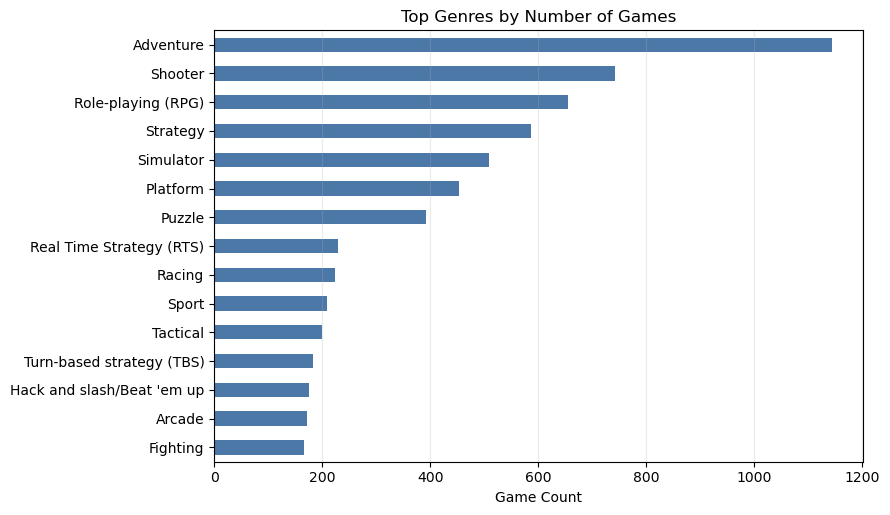

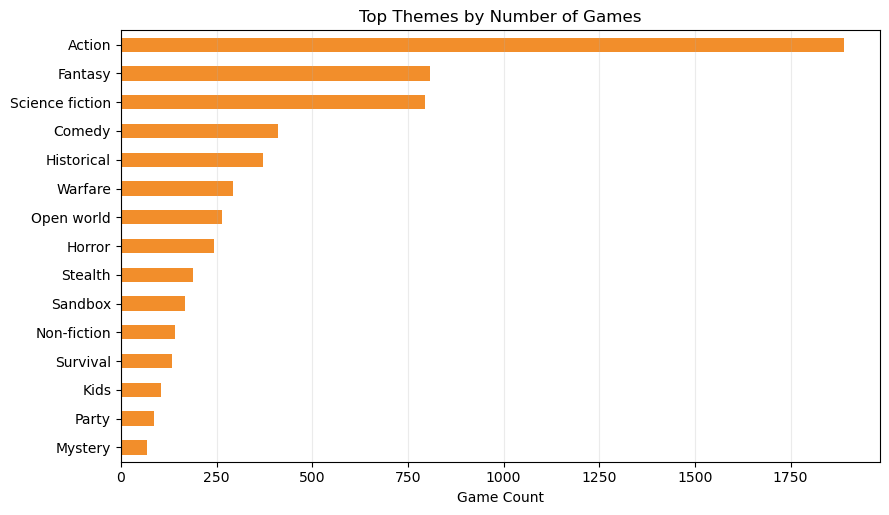

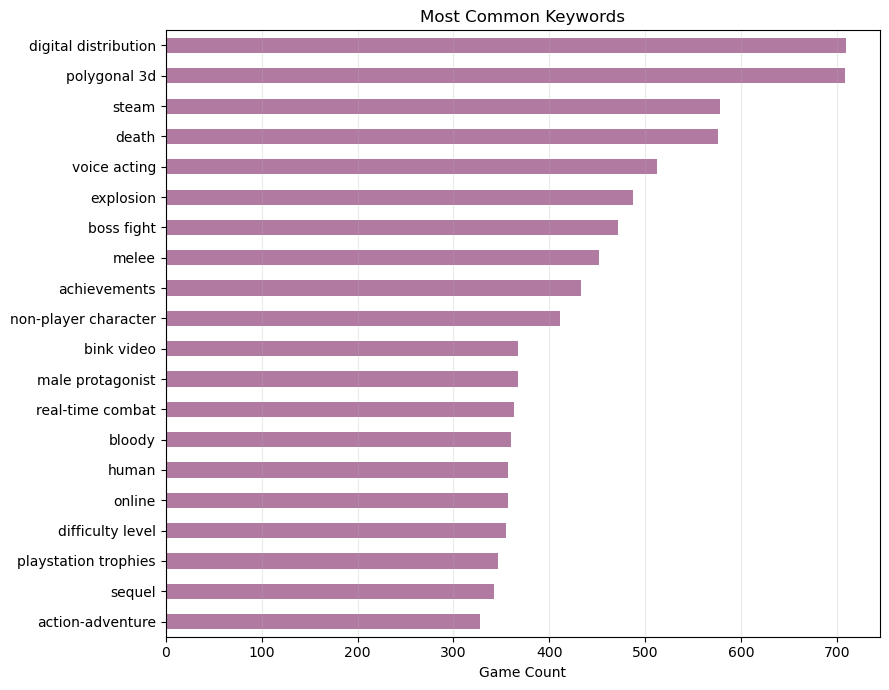

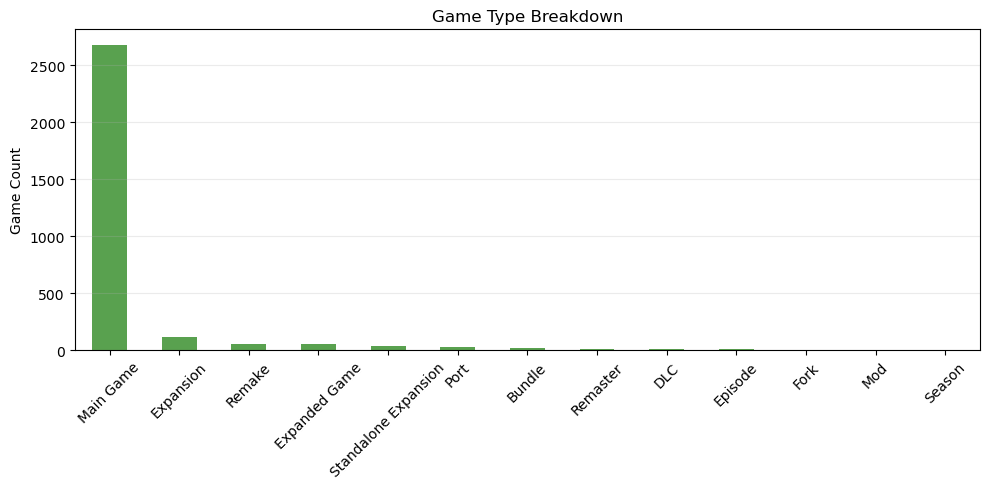

In [7]:
plot_barh(top_genres, 'genre_name', 'game_count', 'Top Genres by Number of Games', top_n=15)
plot_barh(top_themes, 'theme_name', 'game_count', 'Top Themes by Number of Games', top_n=15, color='#F28E2B')
plot_barh(top_keywords, 'keyword_name', 'game_count', 'Most Common Keywords', top_n=20, color='#B07AA1')
plot_bar(game_type_breakdown, 'game_type', 'game_count', 'Game Type Breakdown', color='#59A14F')

# 4. Platform Coverage

These queries answer where games in the project catalog can be played. Platform counts are relationship-based, so totals across platform bars should not be summed as unique games.

In [8]:
top_platforms = run_query('''
SELECT
    p.name AS platform_name,
    COALESCE(p.abbreviation, '') AS platform_abbreviation,
    COUNT(DISTINCT g.game_id) AS game_count
FROM games g
JOIN game_platforms gp
    ON g.game_id = gp.game_id
JOIN platforms p
    ON gp.platform_id = p.platform_id
GROUP BY p.name, p.abbreviation
ORDER BY game_count DESC, p.name;
''')

platform_family_distribution = run_query('''
SELECT
    COALESCE(pf.name, 'Unknown / No Family') AS platform_family,
    COUNT(DISTINCT g.game_id) AS game_count
FROM games g
JOIN game_platforms gp
    ON g.game_id = gp.game_id
JOIN platforms p
    ON gp.platform_id = p.platform_id
LEFT JOIN platform_families pf
    ON p.platform_family_id = pf.platform_family_id
GROUP BY COALESCE(pf.name, 'Unknown / No Family')
ORDER BY game_count DESC, platform_family;
''')

platform_type_distribution = run_query('''
SELECT
    COALESCE(pt.name, 'Unknown / No Type') AS platform_type,
    COUNT(DISTINCT g.game_id) AS game_count
FROM games g
JOIN game_platforms gp
    ON g.game_id = gp.game_id
JOIN platforms p
    ON gp.platform_id = p.platform_id
LEFT JOIN platform_types pt
    ON p.platform_type_id = pt.platform_type_id
GROUP BY COALESCE(pt.name, 'Unknown / No Type')
ORDER BY game_count DESC, platform_type;
''')

tables_to_export.update({
    'top_platforms': top_platforms,
    'platform_family_distribution': platform_family_distribution,
    'platform_type_distribution': platform_type_distribution,
})

display(top_platforms.head(25))
display(platform_family_distribution)
display(platform_type_distribution)

,platform_name,platform_abbreviation,game_count
0,PC (Microsoft Windows),PC,1568
1,Mac,Mac,660
2,PlayStation 3,PS3,565
3,Xbox 360,X360,539
4,DOS,DOS,455
5,PlayStation 2,PS2,358
6,Linux,Linux,288
7,Wii,Wii,239
8,PlayStation,PS1,206
9,Xbox,XBOX,206


,platform_family,game_count
0,Unknown / No Family,2004
1,PlayStation,1133
2,Nintendo,923
3,Xbox,784
4,Linux,365
5,Sega,157


,platform_type,game_count
0,Operating_system,1881
1,Console,1685
2,Portable_console,567
3,Computer,229
4,Arcade,121
5,Platform,31
6,Unknown / No Type,3


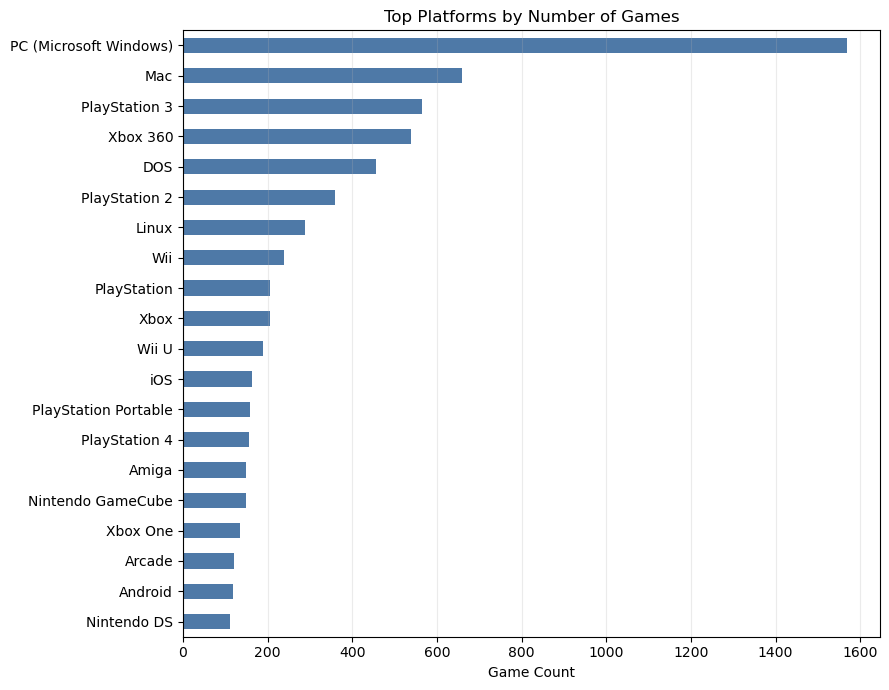

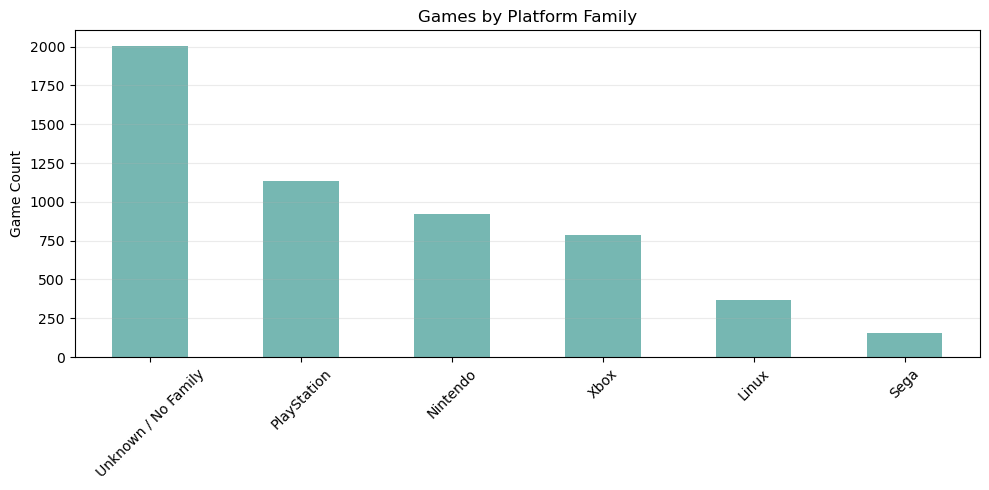

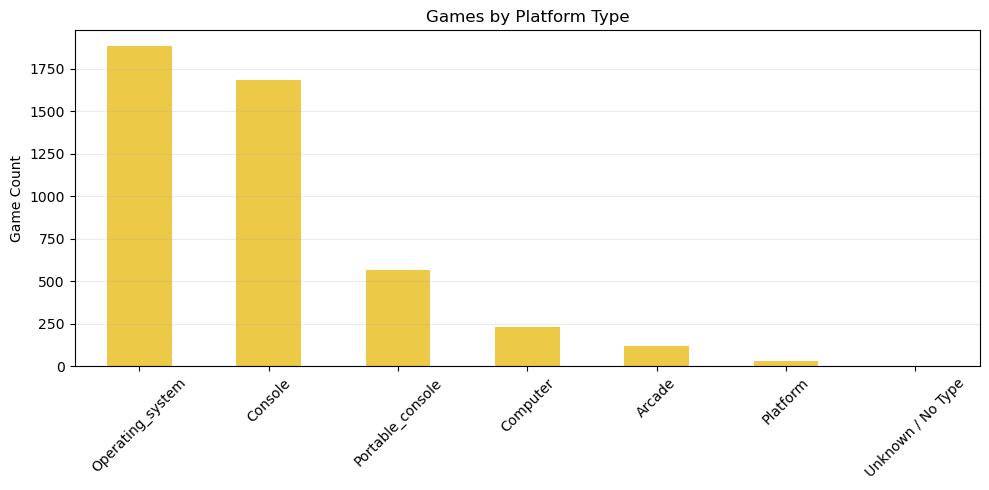

In [9]:
plot_barh(top_platforms, 'platform_name', 'game_count', 'Top Platforms by Number of Games', top_n=20, color='#4E79A7')
plot_bar(platform_family_distribution, 'platform_family', 'game_count', 'Games by Platform Family', color='#76B7B2')
plot_bar(platform_type_distribution, 'platform_type', 'game_count', 'Games by Platform Type', color='#EDC948')

# 5. Release Timeline

The year-level charts use `games.release_year` for game-level first-release trends. Platform-specific release timing should use `release_dates` and should be interpreted separately.

In [10]:
games_by_release_year = run_query('''
SELECT
    release_year,
    COUNT(DISTINCT game_id) AS game_count
FROM games
WHERE release_year IS NOT NULL
GROUP BY release_year
ORDER BY release_year;
''')

games_by_release_decade = run_query('''
WITH decade_bins AS (
    SELECT
        game_id,
        CASE
            WHEN release_year IS NULL THEN 'Unknown'
            WHEN release_year < 1980 THEN 'Before 1980'
            WHEN release_year BETWEEN 1980 AND 1989 THEN '1980s'
            WHEN release_year BETWEEN 1990 AND 1999 THEN '1990s'
            WHEN release_year BETWEEN 2000 AND 2009 THEN '2000s'
            WHEN release_year BETWEEN 2010 AND 2019 THEN '2010s'
            WHEN release_year BETWEEN 2020 AND 2029 THEN '2020s'
            ELSE 'Future / Other'
        END AS release_decade,
        CASE
            WHEN release_year IS NULL THEN 99
            WHEN release_year < 1980 THEN 1
            WHEN release_year BETWEEN 1980 AND 1989 THEN 2
            WHEN release_year BETWEEN 1990 AND 1999 THEN 3
            WHEN release_year BETWEEN 2000 AND 2009 THEN 4
            WHEN release_year BETWEEN 2010 AND 2019 THEN 5
            WHEN release_year BETWEEN 2020 AND 2029 THEN 6
            ELSE 7
        END AS sort_order
    FROM games
)
SELECT
    release_decade,
    COUNT(DISTINCT game_id) AS game_count
FROM decade_bins
GROUP BY release_decade, sort_order
ORDER BY sort_order;
''')

release_decade_by_platform_type = run_query('''
WITH game_decades AS (
    SELECT
        game_id,
        CASE
            WHEN release_year IS NULL THEN 'Unknown'
            WHEN release_year < 1980 THEN 'Before 1980'
            WHEN release_year BETWEEN 1980 AND 1989 THEN '1980s'
            WHEN release_year BETWEEN 1990 AND 1999 THEN '1990s'
            WHEN release_year BETWEEN 2000 AND 2009 THEN '2000s'
            WHEN release_year BETWEEN 2010 AND 2019 THEN '2010s'
            WHEN release_year BETWEEN 2020 AND 2029 THEN '2020s'
            ELSE 'Future / Other'
        END AS release_decade,
        CASE
            WHEN release_year IS NULL THEN 99
            WHEN release_year < 1980 THEN 1
            WHEN release_year BETWEEN 1980 AND 1989 THEN 2
            WHEN release_year BETWEEN 1990 AND 1999 THEN 3
            WHEN release_year BETWEEN 2000 AND 2009 THEN 4
            WHEN release_year BETWEEN 2010 AND 2019 THEN 5
            WHEN release_year BETWEEN 2020 AND 2029 THEN 6
            ELSE 7
        END AS sort_order
    FROM games
)
SELECT
    gd.release_decade,
    gd.sort_order,
    COALESCE(pt.name, 'Unknown / No Type') AS platform_type,
    COUNT(DISTINCT gd.game_id) AS game_count
FROM game_decades gd
JOIN game_platforms gp
    ON gd.game_id = gp.game_id
JOIN platforms p
    ON gp.platform_id = p.platform_id
LEFT JOIN platform_types pt
    ON p.platform_type_id = pt.platform_type_id
GROUP BY gd.release_decade, gd.sort_order, COALESCE(pt.name, 'Unknown / No Type')
ORDER BY gd.sort_order, platform_type;
''')

tables_to_export.update({
    'games_by_release_year': games_by_release_year,
    'games_by_release_decade': games_by_release_decade,
    'release_decade_by_platform_type': release_decade_by_platform_type,
})

display(games_by_release_year.head())
display(games_by_release_year.tail())
display(games_by_release_decade)
display(release_decade_by_platform_type.head(30))

,release_year,game_count
0,1972,1
1,1976,1
2,1977,1
3,1978,4
4,1979,1


,release_year,game_count
42,2017,2
43,2018,5
44,2019,2
45,2020,2
46,2021,1


,release_decade,game_count
0,Before 1980,8
1,1980s,191
2,1990s,817
3,2000s,1318
4,2010s,640
5,2020s,3
6,Unknown,23


,release_decade,sort_order,platform_type,game_count
0,Before 1980,1,Arcade,3
1,Before 1980,1,Computer,6
2,Before 1980,1,Console,1
3,Before 1980,1,Operating_system,4
4,Before 1980,1,Platform,1
5,Before 1980,1,Portable_console,1
6,1980s,2,Arcade,39
7,1980s,2,Computer,121
8,1980s,2,Console,66
9,1980s,2,Operating_system,123


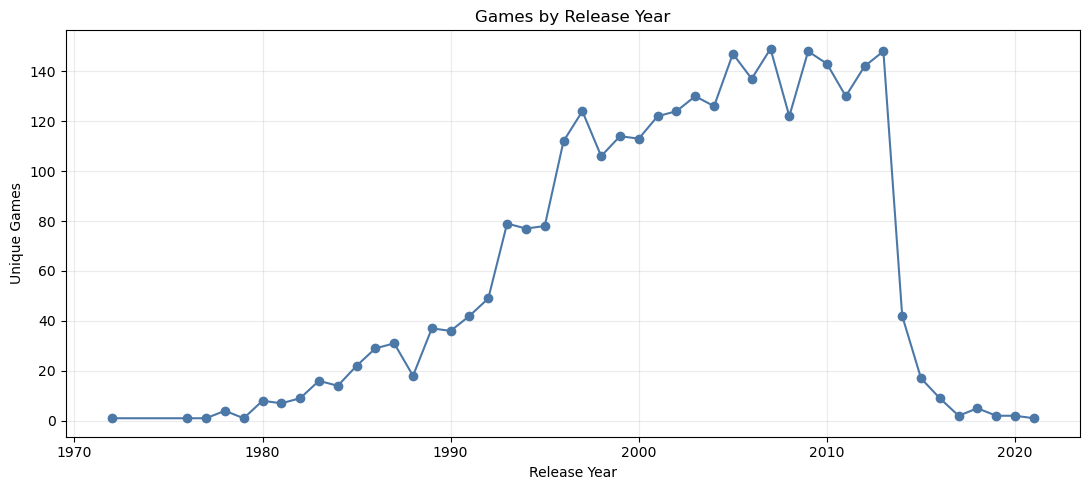

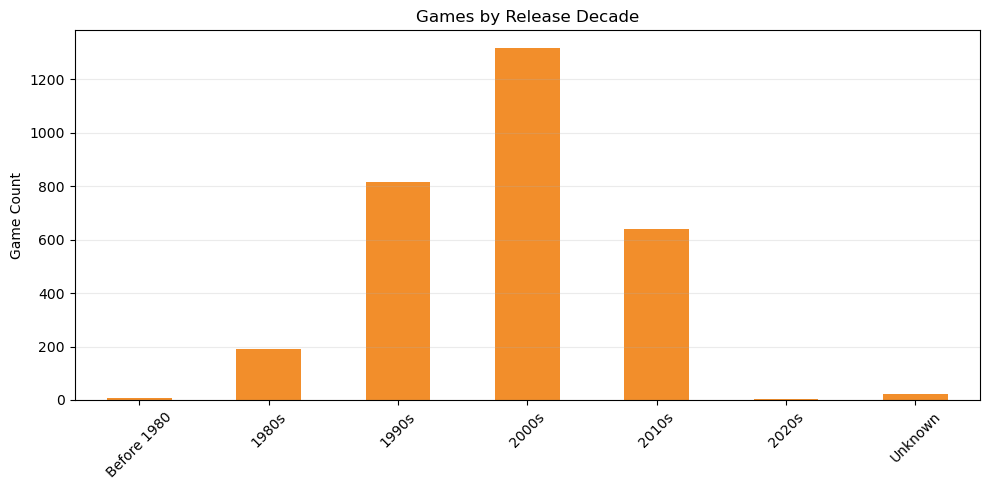

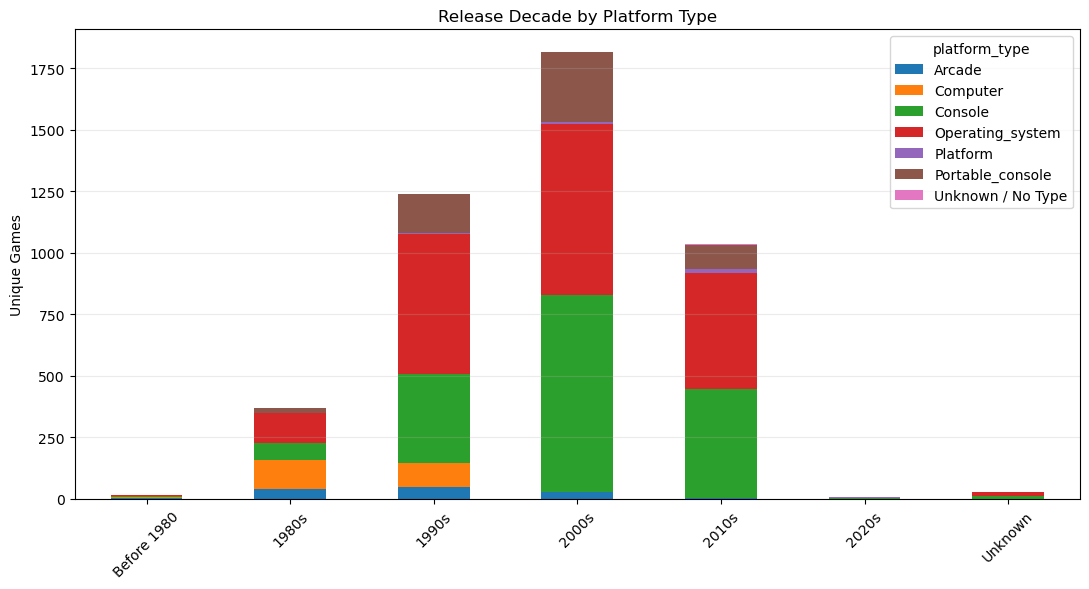

In [11]:
if not games_by_release_year.empty:
    ax = games_by_release_year.plot.line(x='release_year', y='game_count', marker='o', figsize=(11, 5), legend=False, color='#4C78A8')
    ax.set_title('Games by Release Year')
    ax.set_xlabel('Release Year')
    ax.set_ylabel('Unique Games')
    ax.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

plot_bar(games_by_release_decade, 'release_decade', 'game_count', 'Games by Release Decade', color='#F28E2B')

if not release_decade_by_platform_type.empty:
    platform_pivot = release_decade_by_platform_type.pivot_table(
        index='release_decade',
        columns='platform_type',
        values='game_count',
        aggfunc='sum',
        fill_value=0,
    )
    platform_pivot = platform_pivot.reindex(games_by_release_decade['release_decade'])
    ax = platform_pivot.plot(kind='bar', stacked=True, figsize=(11, 6))
    ax.set_title('Release Decade by Platform Type')
    ax.set_xlabel('')
    ax.set_ylabel('Unique Games')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(axis='y', alpha=0.25)
    plt.tight_layout()
    plt.show()

# 6. Rating and Popularity Overview

This section describes quality-score coverage, rating bands, rating-count skew, and popularity signal availability. `total_rating_count` is used as the primary descriptive proxy for rating confidence and visibility. Popularity primitives are summarized by source/type and are not combined into a single popularity score.

In [12]:
game_base = run_query('''
SELECT
    game_id,
    name,
    release_year,
    rating,
    rating_count,
    aggregated_rating,
    aggregated_rating_count,
    total_rating,
    total_rating_count
FROM games;
''')

rating_bands = run_query('''
SELECT
    CASE
        WHEN total_rating IS NULL THEN 'Unrated / insufficient data'
        WHEN total_rating >= 90 THEN 'Excellent'
        WHEN total_rating >= 80 THEN 'Highly rated'
        WHEN total_rating >= 70 THEN 'Good'
        WHEN total_rating >= 60 THEN 'Mixed / average'
        ELSE 'Lower rated'
    END AS rating_band,
    COUNT(DISTINCT game_id) AS game_count
FROM games
GROUP BY rating_band
ORDER BY
    CASE rating_band
        WHEN 'Excellent' THEN 1
        WHEN 'Highly rated' THEN 2
        WHEN 'Good' THEN 3
        WHEN 'Mixed / average' THEN 4
        WHEN 'Lower rated' THEN 5
        ELSE 6
    END;
''')

rating_coverage = run_query('''
SELECT
    COUNT(*) AS total_games,
    SUM(CASE WHEN total_rating IS NOT NULL THEN 1 ELSE 0 END) AS games_with_total_rating,
    SUM(CASE WHEN total_rating_count IS NOT NULL THEN 1 ELSE 0 END) AS games_with_total_rating_count,
    SUM(CASE WHEN rating IS NOT NULL THEN 1 ELSE 0 END) AS games_with_user_rating,
    SUM(CASE WHEN rating_count IS NOT NULL THEN 1 ELSE 0 END) AS games_with_user_rating_count,
    SUM(CASE WHEN aggregated_rating IS NOT NULL THEN 1 ELSE 0 END) AS games_with_critic_rating,
    SUM(CASE WHEN aggregated_rating_count IS NOT NULL THEN 1 ELSE 0 END) AS games_with_critic_rating_count
FROM games;
''')

popularity_signal_availability = run_query('''
SELECT
    COALESCE(egs.source_name, 'Unknown Source') AS popularity_source,
    COALESCE(pt.name, 'Unknown Popularity Type') AS popularity_type,
    COUNT(DISTINCT pp.game_id) AS games_with_signal,
    COUNT(*) AS signal_records
FROM popularity_primitives pp
LEFT JOIN popularity_types pt
    ON pp.popularity_type_id = pt.popularity_type_id
LEFT JOIN external_game_sources egs
    ON pp.external_popularity_source_id = egs.external_game_source_id
GROUP BY
    COALESCE(egs.source_name, 'Unknown Source'),
    COALESCE(pt.name, 'Unknown Popularity Type')
ORDER BY games_with_signal DESC, signal_records DESC;
''')

tables_to_export.update({
    'game_base_rating_fields': game_base,
    'rating_bands': rating_bands,
    'rating_coverage': rating_coverage,
    'popularity_signal_availability': popularity_signal_availability,
})

display(game_base[['total_rating', 'total_rating_count']].describe())
display(rating_bands)
display(rating_coverage)
display(popularity_signal_availability)

,total_rating,total_rating_count
count,"2,603.00","2,603.00"
mean,73.64,183.31
std,11.86,410.62
min,10.02,0.00
25%,68.52,16.00
50%,75.94,48.00
75%,81.72,165.50
max,99.49,"5,801.00"


,rating_band,game_count
0,Excellent,64
1,Highly rated,787
2,Good,988
3,Mixed / average,463
4,Lower rated,301
5,Unrated / insufficient data,397


,total_games,games_with_total_rating,games_with_total_rating_count,games_with_user_rating,games_with_user_rating_count,games_with_critic_rating,games_with_critic_rating_count
0,3000,2603,2603,2529,2529,1799,1799


,popularity_source,popularity_type,games_with_signal,signal_records
0,IGDB,Played,2978,2978
1,IGDB,Want to Play,2745,2745
2,IGDB,Visits,2081,2081
3,IGDB,Playing,1904,1904
4,Twitch,24hr Hours Watched,1496,1496
5,Steam,Negative Reviews,763,763
6,Steam,Total Reviews,761,761
7,Steam,Postitive Reviews,761,761
8,Steam,24hr Peak Players,761,761
9,Steam,Global Top Sellers,292,292


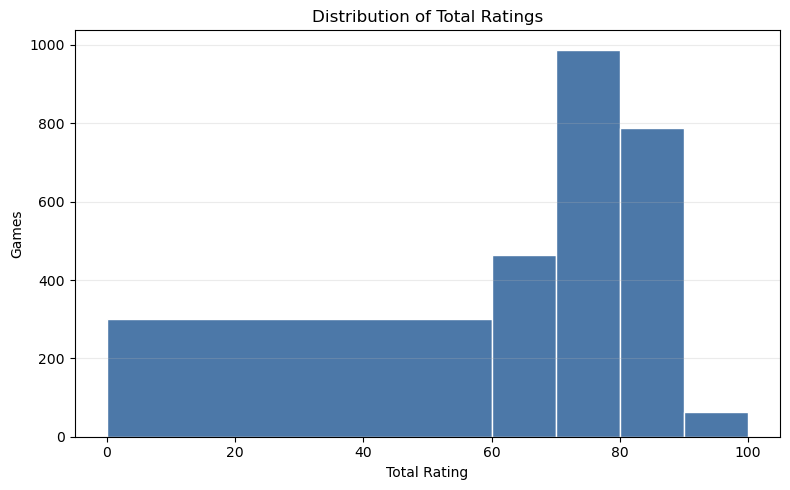

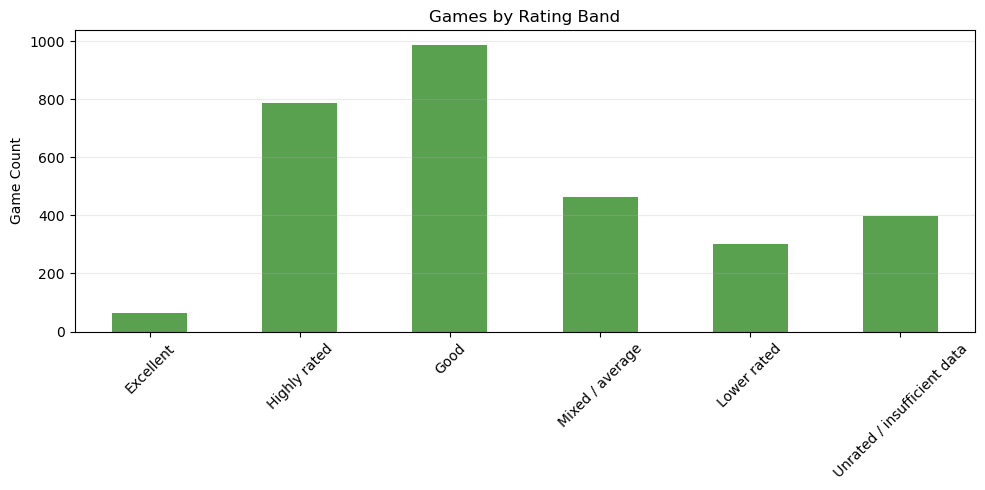

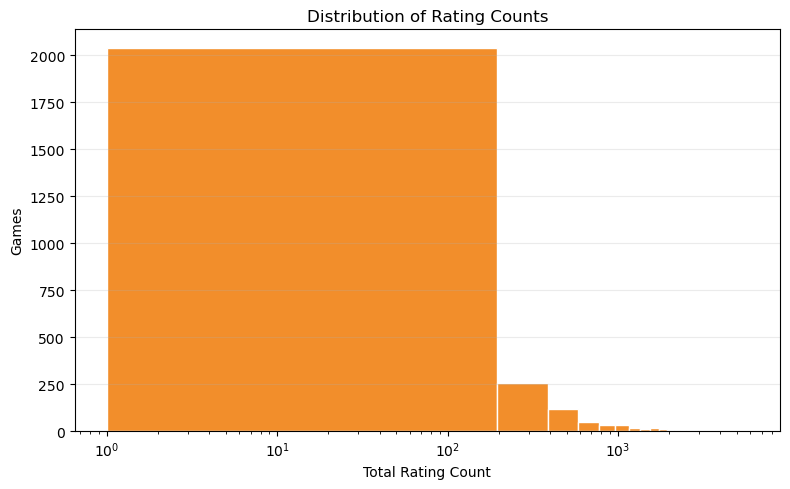

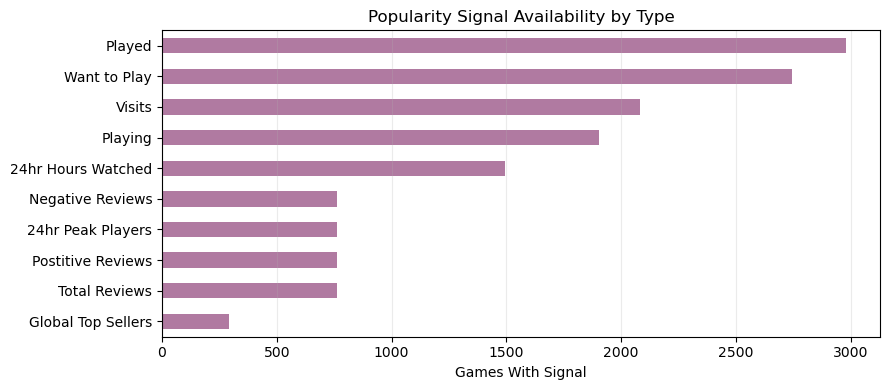

In [13]:
rating_values = game_base['total_rating'].dropna()
if not rating_values.empty:
    ax = rating_values.plot.hist(bins=[0, 60, 70, 80, 90, 100], figsize=(8, 5), color='#4C78A8', edgecolor='white')
    ax.set_title('Distribution of Total Ratings')
    ax.set_xlabel('Total Rating')
    ax.set_ylabel('Games')
    ax.grid(axis='y', alpha=0.25)
    plt.tight_layout()
    plt.show()

plot_bar(rating_bands, 'rating_band', 'game_count', 'Games by Rating Band', color='#59A14F')

rating_counts = game_base['total_rating_count'].dropna()
if not rating_counts.empty:
    positive_counts = rating_counts[rating_counts > 0]
    ax = positive_counts.plot.hist(bins=30, figsize=(8, 5), color='#F28E2B', edgecolor='white')
    ax.set_title('Distribution of Rating Counts')
    ax.set_xlabel('Total Rating Count')
    ax.set_ylabel('Games')
    if positive_counts.max() > 0:
        ax.set_xscale('log')
    ax.grid(axis='y', alpha=0.25)
    plt.tight_layout()
    plt.show()

plot_barh(popularity_signal_availability, 'popularity_type', 'games_with_signal', 'Popularity Signal Availability by Type', top_n=20, color='#B07AA1')

# 7. Developer and Publisher Overview

Developer and publisher analysis uses role flags in `involved_companies`. Do not treat every involved company as a developer or publisher.

In [14]:
top_developers = run_query('''
SELECT
    c.name AS developer_name,
    COUNT(DISTINCT ic.game_id) AS game_count
FROM involved_companies ic
JOIN companies c
    ON ic.company_id = c.company_id
WHERE ic.developer = 1
GROUP BY c.name
ORDER BY game_count DESC, c.name
LIMIT 25;
''')

top_publishers = run_query('''
SELECT
    c.name AS publisher_name,
    COUNT(DISTINCT ic.game_id) AS game_count
FROM involved_companies ic
JOIN companies c
    ON ic.company_id = c.company_id
WHERE ic.publisher = 1
GROUP BY c.name
ORDER BY game_count DESC, c.name
LIMIT 25;
''')

company_role_coverage = run_query('''
SELECT 'Developer' AS role_name,
       COUNT(*) AS relationship_count,
       COUNT(DISTINCT game_id) AS game_count
FROM involved_companies
WHERE developer = 1

UNION ALL
SELECT 'Publisher',
       COUNT(*),
       COUNT(DISTINCT game_id)
FROM involved_companies
WHERE publisher = 1

UNION ALL
SELECT 'Porting',
       COUNT(*),
       COUNT(DISTINCT game_id)
FROM involved_companies
WHERE porting = 1

UNION ALL
SELECT 'Supporting',
       COUNT(*),
       COUNT(DISTINCT game_id)
FROM involved_companies
WHERE supporting = 1;
''')

tables_to_export.update({
    'top_developers': top_developers,
    'top_publishers': top_publishers,
    'company_role_coverage': company_role_coverage,
})

display(top_developers)
display(top_publishers)
display(company_role_coverage)

,developer_name,game_count
0,Capcom,71
1,Konami,50
2,LucasArts,36
3,EA Canada,34
4,Nintendo Entertainment Analysis & Development,29
5,Sierra On-Line,29
6,Intelligent Systems,28
7,Nintendo,25
8,Ubisoft Montreal,25
9,Nintendo R&D1,24


,publisher_name,game_count
0,Nintendo,268
1,Electronic Arts,262
2,Sony Computer Entertainment,141
3,Capcom,137
4,Activision,122
5,Square Enix,106
6,Konami,100
7,THQ,94
8,Sega,86
9,LucasArts,78


,role_name,relationship_count,game_count
0,Developer,3520,2959
1,Publisher,4707,2930
2,Porting,445,324
3,Supporting,276,170


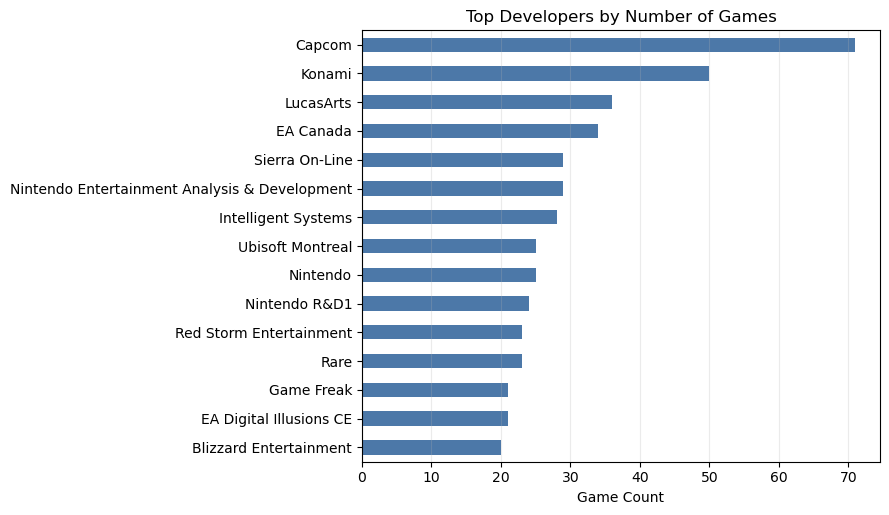

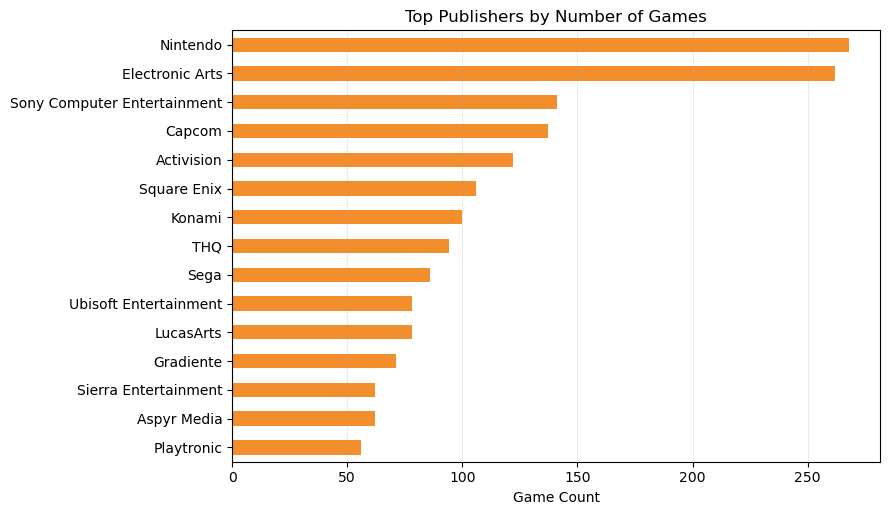

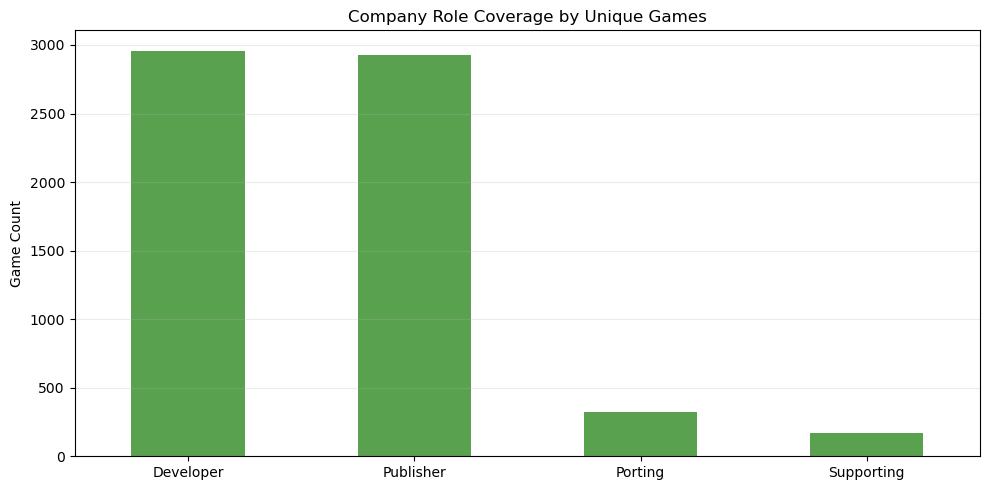

In [15]:
plot_barh(top_developers, 'developer_name', 'game_count', 'Top Developers by Number of Games', top_n=15, color='#4C78A8')
plot_barh(top_publishers, 'publisher_name', 'game_count', 'Top Publishers by Number of Games', top_n=15, color='#F28E2B')
plot_bar(company_role_coverage, 'role_name', 'game_count', 'Company Role Coverage by Unique Games', color='#59A14F', rotation=0)

# 8. Metadata Completeness and Data Quality

This section documents which fields and relationships are complete enough for later diagnostic, predictive, recommendation, and RAG work.

In [16]:
field_completeness_sql = '''
SELECT
    game_id,
    name,
    summary,
    storyline,
    first_release_date,
    first_release_date_iso,
    release_year,
    rating,
    rating_count,
    aggregated_rating,
    aggregated_rating_count,
    total_rating,
    total_rating_count,
    game_type_id,
    game_status_id,
    cover_id,
    updated_at_iso
FROM games;
'''
field_source = run_query(field_completeness_sql)

field_rows = []
text_fields = {'name', 'summary', 'storyline', 'first_release_date_iso', 'updated_at_iso'}
for column in field_source.columns:
    if column == 'game_id':
        continue
    if column in text_fields:
        non_null_count = field_source[column].fillna('').astype(str).str.strip().ne('').sum()
    else:
        non_null_count = field_source[column].notna().sum()
    total_records = len(field_source)
    field_rows.append({
        'field_name': column,
        'total_records': total_records,
        'non_null_count': int(non_null_count),
        'missing_count': int(total_records - non_null_count),
        'completion_rate': round(100 * non_null_count / total_records, 2) if total_records else 0,
    })

field_completeness = pd.DataFrame(field_rows).sort_values(['completion_rate', 'field_name'], ascending=[True, True])
tables_to_export['field_completeness'] = field_completeness
display(field_completeness)

,field_name,total_records,non_null_count,missing_count,completion_rate
13,game_status_id,3000,109,2891,3.63
2,storyline,3000,1070,1930,35.67
8,aggregated_rating,3000,1799,1201,59.97
9,aggregated_rating_count,3000,1799,1201,59.97
6,rating,3000,2529,471,84.30
7,rating_count,3000,2529,471,84.30
10,total_rating,3000,2603,397,86.77
11,total_rating_count,3000,2603,397,86.77
1,summary,3000,2933,67,97.77
3,first_release_date,3000,2977,23,99.23


In [17]:
relationship_coverage_wide = run_query('''
WITH
genre_games AS (
    SELECT DISTINCT game_id FROM game_genres
),
theme_games AS (
    SELECT DISTINCT game_id FROM game_themes
),
keyword_games AS (
    SELECT DISTINCT game_id FROM game_keywords
),
platform_games AS (
    SELECT DISTINCT game_id FROM game_platforms
),
company_games AS (
    SELECT DISTINCT game_id FROM involved_companies
),
release_date_games AS (
    SELECT DISTINCT game_id FROM release_dates
),
cover_games AS (
    SELECT DISTINCT game_id FROM covers
),
website_games AS (
    SELECT DISTINCT game_id FROM websites
)
SELECT
    COUNT(DISTINCT g.game_id) AS total_games,
    COUNT(DISTINCT gg.game_id) AS games_with_genre,
    COUNT(DISTINCT tg.game_id) AS games_with_theme,
    COUNT(DISTINCT kg.game_id) AS games_with_keyword,
    COUNT(DISTINCT pg.game_id) AS games_with_platform,
    COUNT(DISTINCT cg.game_id) AS games_with_company,
    COUNT(DISTINCT rdg.game_id) AS games_with_release_date,
    COUNT(DISTINCT cov.game_id) AS games_with_cover,
    COUNT(DISTINCT wg.game_id) AS games_with_website
FROM games g
LEFT JOIN genre_games gg
    ON g.game_id = gg.game_id
LEFT JOIN theme_games tg
    ON g.game_id = tg.game_id
LEFT JOIN keyword_games kg
    ON g.game_id = kg.game_id
LEFT JOIN platform_games pg
    ON g.game_id = pg.game_id
LEFT JOIN company_games cg
    ON g.game_id = cg.game_id
LEFT JOIN release_date_games rdg
    ON g.game_id = rdg.game_id
LEFT JOIN cover_games cov
    ON g.game_id = cov.game_id
LEFT JOIN website_games wg
    ON g.game_id = wg.game_id;
''')

total_games = int(relationship_coverage_wide.loc[0, 'total_games'])
relationship_rows = []
for column in relationship_coverage_wide.columns:
    if column == 'total_games':
        continue
    value = int(relationship_coverage_wide.loc[0, column])
    relationship_rows.append({
        'relationship': column.replace('games_with_', '').replace('_', ' ').title(),
        'games_with_relationship': value,
        'total_games': total_games,
        'coverage_rate': round(100 * value / total_games, 2) if total_games else 0,
    })

relationship_coverage = pd.DataFrame(relationship_rows).sort_values('coverage_rate')
tables_to_export['relationship_coverage'] = relationship_coverage
display(relationship_coverage)

,relationship,games_with_relationship,total_games,coverage_rate
2,Keyword,2836,3000,94.53
1,Theme,2867,3000,95.57
7,Website,2962,3000,98.73
4,Company,2983,3000,99.43
0,Genre,2994,3000,99.80
6,Cover,2994,3000,99.80
5,Release Date,2996,3000,99.87
3,Platform,2999,3000,99.97


In [18]:
def scalar(sql):
    return run_query(sql).iloc[0, 0]


dq_rows = []
dq_rows.append({
    'check_name': 'SQLite integrity check',
    'expected_result': 'ok',
    'actual_result': str(integrity_check.iloc[0, 0]),
    'failing_rows': 0 if str(integrity_check.iloc[0, 0]).lower() == 'ok' else 1,
})
dq_rows.append({
    'check_name': 'Foreign key failures',
    'expected_result': '0',
    'actual_result': str(len(foreign_key_check)),
    'failing_rows': len(foreign_key_check),
})
dq_rows.append({
    'check_name': 'Empty core tables',
    'expected_result': '0',
    'actual_result': str(scalar('''
        SELECT COUNT(*)
        FROM (
            SELECT 'games' AS table_name, COUNT(*) AS row_count FROM games
            UNION ALL SELECT 'genres', COUNT(*) FROM genres
            UNION ALL SELECT 'themes', COUNT(*) FROM themes
            UNION ALL SELECT 'platforms', COUNT(*) FROM platforms
            UNION ALL SELECT 'game_genres', COUNT(*) FROM game_genres
            UNION ALL SELECT 'game_platforms', COUNT(*) FROM game_platforms
        )
        WHERE row_count = 0;
    ''')),
    'failing_rows': int(scalar('''
        SELECT COUNT(*)
        FROM (
            SELECT 'games' AS table_name, COUNT(*) AS row_count FROM games
            UNION ALL SELECT 'genres', COUNT(*) FROM genres
            UNION ALL SELECT 'themes', COUNT(*) FROM themes
            UNION ALL SELECT 'platforms', COUNT(*) FROM platforms
            UNION ALL SELECT 'game_genres', COUNT(*) FROM game_genres
            UNION ALL SELECT 'game_platforms', COUNT(*) FROM game_platforms
        )
        WHERE row_count = 0;
    ''')),
})

dq_sql_checks = {
    'Missing required game names': '''
        SELECT COUNT(*) FROM games
        WHERE name IS NULL OR TRIM(name) = '';
    ''',
    'Invalid rating ranges': '''
        SELECT COUNT(*) FROM games
        WHERE (rating IS NOT NULL AND (rating < 0 OR rating > 100))
           OR (aggregated_rating IS NOT NULL AND (aggregated_rating < 0 OR aggregated_rating > 100))
           OR (total_rating IS NOT NULL AND (total_rating < 0 OR total_rating > 100));
    ''',
    'Negative rating counts': '''
        SELECT COUNT(*) FROM games
        WHERE (rating_count IS NOT NULL AND rating_count < 0)
           OR (aggregated_rating_count IS NOT NULL AND aggregated_rating_count < 0)
           OR (total_rating_count IS NOT NULL AND total_rating_count < 0);
    ''',
    'Invalid release months': '''
        SELECT COUNT(*) FROM release_dates
        WHERE release_month IS NOT NULL
          AND (release_month < 1 OR release_month > 12);
    ''',
    'Invalid release days': '''
        SELECT COUNT(*) FROM release_dates
        WHERE release_day IS NOT NULL
          AND (release_day < 1 OR release_day > 31);
    ''',
    'Duplicate game-genre relationships': '''
        SELECT COUNT(*) FROM (
            SELECT game_id, genre_id
            FROM game_genres
            GROUP BY game_id, genre_id
            HAVING COUNT(*) > 1
        );
    ''',
    'Duplicate game-theme relationships': '''
        SELECT COUNT(*) FROM (
            SELECT game_id, theme_id
            FROM game_themes
            GROUP BY game_id, theme_id
            HAVING COUNT(*) > 1
        );
    ''',
    'Duplicate game-keyword relationships': '''
        SELECT COUNT(*) FROM (
            SELECT game_id, keyword_id
            FROM game_keywords
            GROUP BY game_id, keyword_id
            HAVING COUNT(*) > 1
        );
    ''',
    'Duplicate game-platform relationships': '''
        SELECT COUNT(*) FROM (
            SELECT game_id, platform_id
            FROM game_platforms
            GROUP BY game_id, platform_id
            HAVING COUNT(*) > 1
        );
    ''',
}

for check_name, sql in dq_sql_checks.items():
    failing_rows = int(scalar(sql))
    dq_rows.append({
        'check_name': check_name,
        'expected_result': '0',
        'actual_result': str(failing_rows),
        'failing_rows': failing_rows,
    })

dq_status_cards = pd.DataFrame(dq_rows)
dq_status_cards['status'] = dq_status_cards['failing_rows'].apply(lambda x: 'PASS' if x == 0 else 'REVIEW')
tables_to_export['dq_status_cards'] = dq_status_cards
display(dq_status_cards)

,check_name,expected_result,actual_result,failing_rows,status
0,SQLite integrity check,ok,ok,0,PASS
1,Foreign key failures,0,0,0,PASS
2,Empty core tables,0,0,0,PASS
3,Missing required game names,0,0,0,PASS
4,Invalid rating ranges,0,0,0,PASS
5,Negative rating counts,0,0,0,PASS
6,Invalid release months,0,0,0,PASS
7,Invalid release days,0,0,0,PASS
8,Duplicate game-genre relationships,0,0,0,PASS
9,Duplicate game-theme relationships,0,0,0,PASS


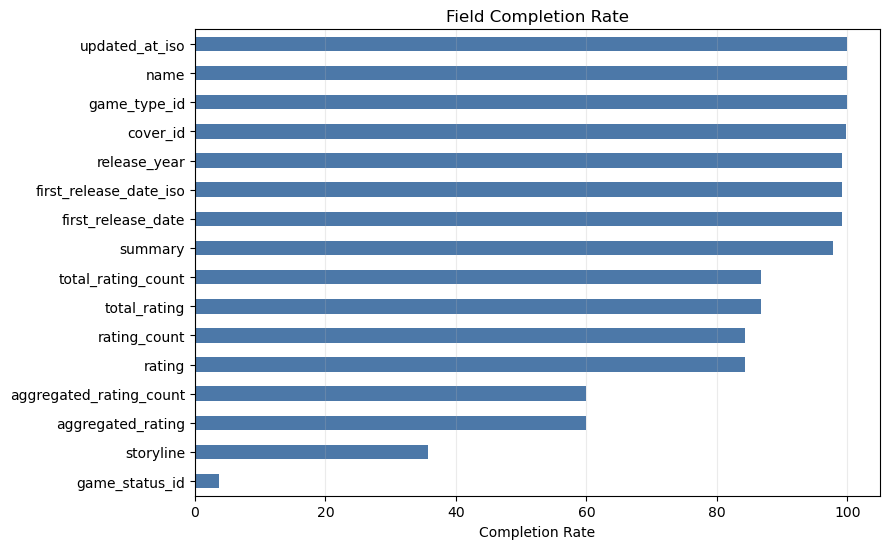

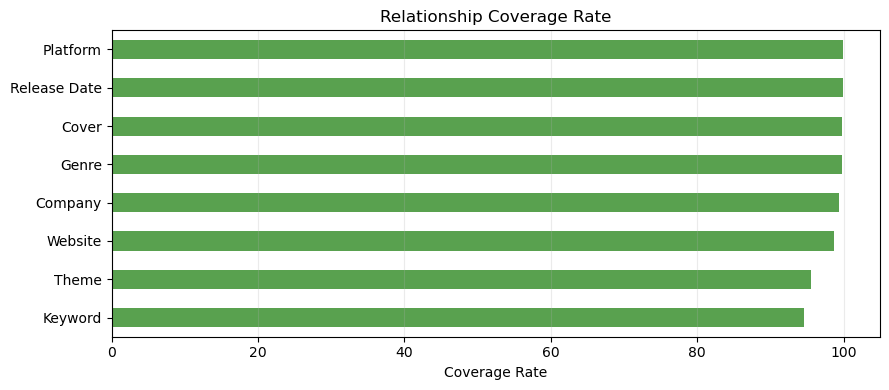

In [19]:
plot_barh(field_completeness.sort_values('completion_rate'), 'field_name', 'completion_rate', 'Field Completion Rate', top_n=len(field_completeness), color='#4C78A8')
plot_barh(relationship_coverage.sort_values('coverage_rate'), 'relationship', 'coverage_rate', 'Relationship Coverage Rate', top_n=len(relationship_coverage), color='#59A14F')

# Optional Add-On: Game Mode and Player Support

This section summarizes play-style metadata such as single-player, multiplayer, co-op, split-screen, and available max-player counts.

Interpretation caveats:

- Game mode counts are not mutually exclusive. A game can be both single-player and multiplayer, so do not use a pie chart or sum the bars as unique games.
- Detailed multiplayer records can be platform-specific, so player support may vary by platform.
- Missing multiplayer detail should be treated as unknown, not as proof that a game is single-player only.
- Max-player fields can contain large online multiplayer outliers, so binned player-count charts are easier to interpret than raw max values.

In [20]:
game_mode_distribution = run_query('''
SELECT
    gm.name AS game_mode,
    COUNT(DISTINCT gmb.game_id) AS game_count
FROM game_modes_bridge gmb
JOIN game_modes gm
    ON gmb.game_mode_id = gm.game_mode_id
GROUP BY gm.name
ORDER BY game_count DESC, gm.name;
''')

multiplayer_by_game = run_query('''
SELECT
    g.game_id,
    g.name,
    CASE WHEN mbg.game_id IS NOT NULL THEN 1 ELSE 0 END AS has_multiplayer_detail,
    COALESCE(mbg.has_campaign_coop, 0) AS has_campaign_coop,
    COALESCE(mbg.has_drop_in, 0) AS has_drop_in,
    COALESCE(mbg.has_lan_coop, 0) AS has_lan_coop,
    COALESCE(mbg.has_offline_coop, 0) AS has_offline_coop,
    COALESCE(mbg.has_online_coop, 0) AS has_online_coop,
    COALESCE(mbg.has_split_screen, 0) AS has_split_screen,
    COALESCE(mbg.max_offline_players, 0) AS max_offline_players,
    COALESCE(mbg.max_online_players, 0) AS max_online_players
FROM games g
LEFT JOIN (
    SELECT
        game_id,
        MAX(CASE WHEN campaign_coop = 1 THEN 1 ELSE 0 END) AS has_campaign_coop,
        MAX(CASE WHEN drop_in = 1 THEN 1 ELSE 0 END) AS has_drop_in,
        MAX(CASE WHEN lan_coop = 1 THEN 1 ELSE 0 END) AS has_lan_coop,
        MAX(CASE WHEN offline_coop = 1 THEN 1 ELSE 0 END) AS has_offline_coop,
        MAX(CASE WHEN online_coop = 1 THEN 1 ELSE 0 END) AS has_online_coop,
        MAX(CASE WHEN split_screen = 1 THEN 1 ELSE 0 END) AS has_split_screen,
        MAX(CASE WHEN COALESCE(offline_coop_max, 0) >= COALESCE(offline_max, 0) THEN COALESCE(offline_coop_max, 0) ELSE COALESCE(offline_max, 0) END) AS max_offline_players,
        MAX(CASE WHEN COALESCE(online_coop_max, 0) >= COALESCE(online_max, 0) THEN COALESCE(online_coop_max, 0) ELSE COALESCE(online_max, 0) END) AS max_online_players
    FROM multiplayer_modes
    GROUP BY game_id
) mbg
    ON g.game_id = mbg.game_id;
''')

total_games = int(kpi_snapshot.loc[kpi_snapshot['kpi'] == 'Total Games', 'value'].iloc[0])
coverage_metrics = [
    ('Games with game mode labels', int(run_query('SELECT COUNT(DISTINCT game_id) AS n FROM game_modes_bridge').iloc[0, 0])),
    ('Games with detailed multiplayer records', int(multiplayer_by_game['has_multiplayer_detail'].sum())),
    ('Games with campaign co-op', int(multiplayer_by_game['has_campaign_coop'].sum())),
    ('Games with drop-in multiplayer', int(multiplayer_by_game['has_drop_in'].sum())),
    ('Games with LAN co-op', int(multiplayer_by_game['has_lan_coop'].sum())),
    ('Games with offline/local co-op', int(multiplayer_by_game['has_offline_coop'].sum())),
    ('Games with online co-op', int(multiplayer_by_game['has_online_coop'].sum())),
    ('Games with split-screen', int(multiplayer_by_game['has_split_screen'].sum())),
    ('Games with offline player max above 0', int((multiplayer_by_game['max_offline_players'] > 0).sum())),
    ('Games with online player max above 0', int((multiplayer_by_game['max_online_players'] > 0).sum())),
]
multiplayer_support_coverage = pd.DataFrame([
    {
        'metric': metric,
        'game_count': game_count,
        'total_games': total_games,
        'pct_of_games': round(100 * game_count / total_games, 2) if total_games else 0,
    }
    for metric, game_count in coverage_metrics
])

player_count_long = []
for count_type, column in [
    ('Offline / local max players', 'max_offline_players'),
    ('Online max players', 'max_online_players'),
]:
    for max_players in multiplayer_by_game.loc[multiplayer_by_game[column] > 0, column]:
        if max_players == 1:
            band = '1 player'
        elif max_players == 2:
            band = '2 players'
        elif max_players <= 4:
            band = '3-4 players'
        elif max_players <= 8:
            band = '5-8 players'
        elif max_players <= 16:
            band = '9-16 players'
        else:
            band = '17+ players'
        player_count_long.append({'player_count_type': count_type, 'player_count_band': band})

player_count_distribution = (
    pd.DataFrame(player_count_long)
    .value_counts(['player_count_type', 'player_count_band'])
    .reset_index(name='game_count')
    if player_count_long else pd.DataFrame(columns=['player_count_type', 'player_count_band', 'game_count'])
)
band_order = ['1 player', '2 players', '3-4 players', '5-8 players', '9-16 players', '17+ players']
player_count_distribution['sort_order'] = player_count_distribution['player_count_band'].map({band: idx for idx, band in enumerate(band_order)})
player_count_distribution = player_count_distribution.sort_values(['player_count_type', 'sort_order']).drop(columns='sort_order')

tables_to_export.update({
    'game_mode_distribution': game_mode_distribution,
    'multiplayer_by_game': multiplayer_by_game,
    'multiplayer_support_coverage': multiplayer_support_coverage,
    'player_count_distribution': player_count_distribution,
})

display(game_mode_distribution)
display(multiplayer_support_coverage)
display(player_count_distribution)
display(multiplayer_by_game[['has_multiplayer_detail', 'max_offline_players', 'max_online_players']].describe().T)

,game_mode,game_count
0,Single player,2867
1,Multiplayer,1501
2,Co-operative,463
3,Split screen,266
4,Massively Multiplayer Online (MMO),83
5,Battle Royale,3


,metric,game_count,total_games,pct_of_games
0,Games with game mode labels,2976,3000,99.20
1,Games with detailed multiplayer records,704,3000,23.47
2,Games with campaign co-op,281,3000,9.37
3,Games with drop-in multiplayer,153,3000,5.10
4,Games with LAN co-op,143,3000,4.77
5,Games with offline/local co-op,260,3000,8.67
6,Games with online co-op,269,3000,8.97
7,Games with split-screen,170,3000,5.67
8,Games with offline player max above 0,430,3000,14.33
9,Games with online player max above 0,353,3000,11.77


,player_count_type,player_count_band,game_count
8,Offline / local max players,1 player,19
0,Offline / local max players,2 players,242
1,Offline / local max players,3-4 players,140
7,Offline / local max players,5-8 players,23
10,Offline / local max players,9-16 players,3
9,Offline / local max players,17+ players,3
4,Online max players,2 players,65
2,Online max players,3-4 players,126
3,Online max players,5-8 players,77
5,Online max players,9-16 players,45


,count,mean,std,min,25%,50%,75%,max
has_multiplayer_detail,"3,000.00",0.23,0.42,0.00,0.00,0.00,0.00,1.00
max_offline_players,"3,000.00",0.45,1.51,0.00,0.00,0.00,0.00,32.00
max_online_players,"3,000.00",3.99,87.06,0.00,0.00,0.00,0.00,"3,500.00"


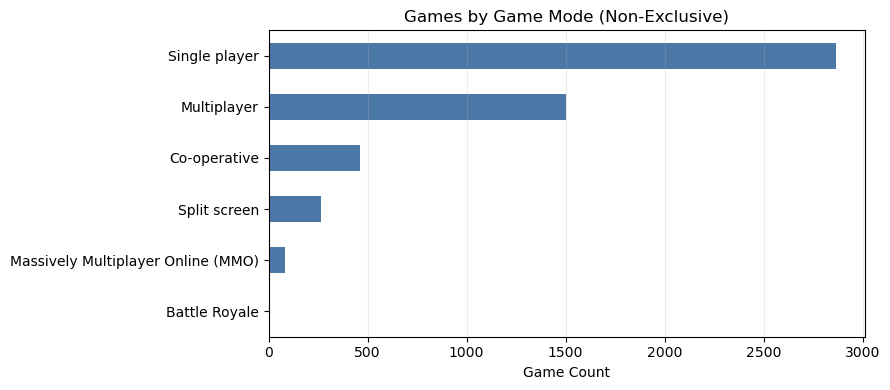

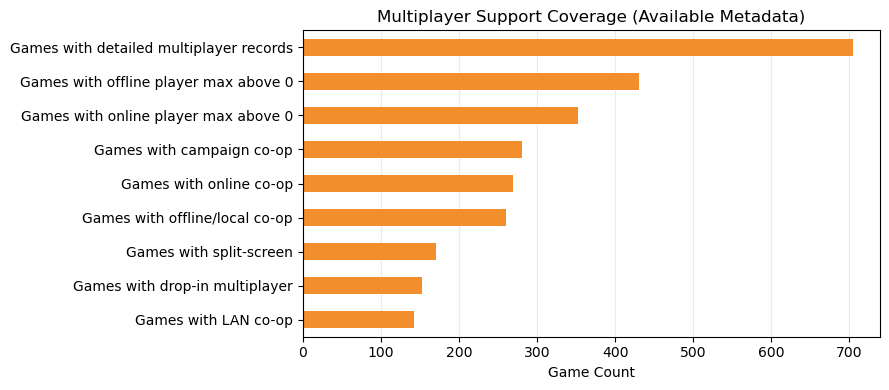

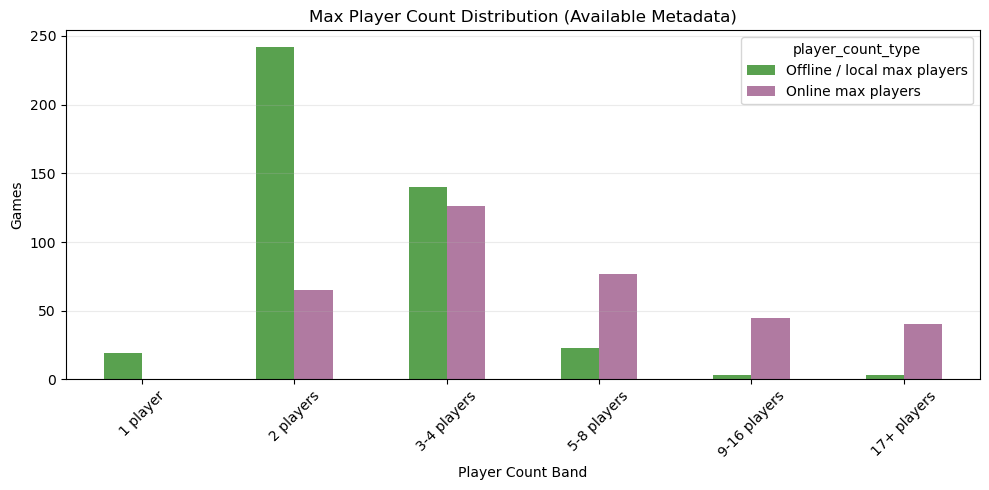

In [21]:
plot_barh(game_mode_distribution, 'game_mode', 'game_count', 'Games by Game Mode (Non-Exclusive)', top_n=len(game_mode_distribution), color='#4C78A8')

support_chart = multiplayer_support_coverage[
    ~multiplayer_support_coverage['metric'].isin(['Games with game mode labels'])
].copy()
plot_barh(support_chart, 'metric', 'game_count', 'Multiplayer Support Coverage (Available Metadata)', top_n=len(support_chart), color='#F28E2B')

if not player_count_distribution.empty:
    player_pivot = player_count_distribution.pivot_table(
        index='player_count_band',
        columns='player_count_type',
        values='game_count',
        aggfunc='sum',
        fill_value=0,
    )
    band_order = ['1 player', '2 players', '3-4 players', '5-8 players', '9-16 players', '17+ players']
    player_pivot = player_pivot.reindex([band for band in band_order if band in player_pivot.index])
    ax = player_pivot.plot(kind='bar', figsize=(10, 5), color=['#59A14F', '#B07AA1'])
    ax.set_title('Max Player Count Distribution (Available Metadata)')
    ax.set_xlabel('Player Count Band')
    ax.set_ylabel('Games')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(axis='y', alpha=0.25)
    plt.tight_layout()
    plt.show()

# 9. Additional Descriptive Exploration

This section expands the descriptive pillar beyond catalog, platform, rating, company, and data-quality coverage. These analyses remain descriptive: they summarize what metadata exists and what the project sample looks like, without explaining rating differences or making recommendations.

## Gameplay Perspective and Playtime

Player perspective counts are non-exclusive. Time-to-beat records only describe games where IGDB has time-to-beat metadata; missing records mean unknown, not zero playtime.

,player_perspective,game_count,total_games,pct_of_games
0,Third person,1189,3000,39.63
1,First person,831,3000,27.70
2,Bird view / Isometric,789,3000,26.30
3,Side view,647,3000,21.57
4,Text,74,3000,2.47
5,Auditory,26,3000,0.87
6,Virtual Reality,9,3000,0.30


,metric,game_count,total_games,pct_of_games
0,Games with time-to-beat record,1059,3000,35.30
1,Games with hastily estimate,668,3000,22.27
2,Games with normally estimate,910,3000,30.33
3,Games with completely estimate,721,3000,24.03
4,Games with time-to-beat submission count,1059,3000,35.30


,playtime_band,game_count,median_normally_hours,p95_normally_hours,max_normally_hours
5,Under 5 hours,119,3.00,4.50,4.96
3,5-9 hours,211,7.38,9.40,9.88
0,10-19 hours,274,13.30,18.50,19.89
1,20-39 hours,174,26.75,38.00,39.65
2,40-79 hours,95,50.20,71.71,75.00
4,80+ hours,37,170.00,"10,889.57","50,059.50"


,game_id,name,hastily_hours,normally_hours,completely_hours,time_to_beat_submission_count,playtime_band
0,234,Guild Wars,"50,049.50","50,059.50","50,299.50",2,80+ hours
1,115,League of Legends,"15,767.38","14,451.86","14,118.38",12,80+ hours
2,3119,Metin2,340.00,"9,999.00",NaN,2,80+ hours
3,123,World of Warcraft,"4,124.00","6,616.67","14,780.00",10,80+ hours
4,1912,Warface,NaN,"3,250.00",NaN,2,80+ hours
5,1014,APB Reloaded,9.00,"2,128.00","14,392.00",3,80+ hours
6,2963,Dota 2,357.04,"1,506.59","5,826.68",13,80+ hours
7,307,Counter-Strike: Source,NaN,"1,337.00",NaN,1,80+ hours
8,121,Minecraft: Java Edition,117.44,"1,044.60","22,761.73",17,80+ hours
9,2903,Warframe,35.00,847.00,"1,792.00",10,80+ hours


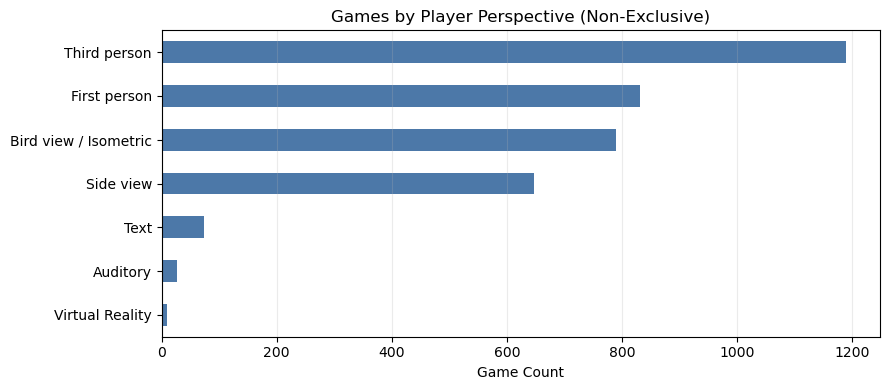

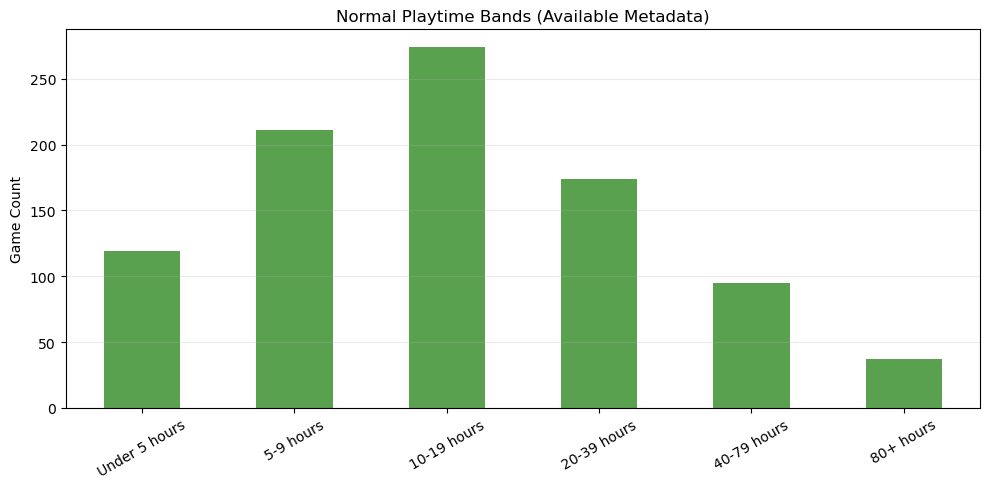

In [22]:
display_section(
    'Gameplay Perspective and Playtime',
    'Player perspective counts are non-exclusive. Time-to-beat records only describe games where IGDB has time-to-beat metadata; missing records mean unknown, not zero playtime.'
)

player_perspective_distribution = run_query('''
WITH total AS (
    SELECT COUNT(DISTINCT game_id) AS total_games
    FROM games
)
SELECT
    pp.name AS player_perspective,
    COUNT(DISTINCT gpp.game_id) AS game_count,
    total.total_games,
    ROUND(100.0 * COUNT(DISTINCT gpp.game_id) / total.total_games, 2) AS pct_of_games
FROM game_player_perspectives gpp
JOIN player_perspectives pp
    ON gpp.player_perspective_id = pp.player_perspective_id
CROSS JOIN total
GROUP BY pp.name, total.total_games
ORDER BY game_count DESC, pp.name;
''')

time_to_beat_coverage = run_query('''
WITH total AS (
    SELECT COUNT(DISTINCT game_id) AS total_games
    FROM games
), coverage AS (
    SELECT
        COUNT(DISTINCT game_id) AS games_with_time_to_beat,
        COUNT(DISTINCT CASE WHEN hastily IS NOT NULL AND hastily > 0 THEN game_id END) AS games_with_hastily,
        COUNT(DISTINCT CASE WHEN normally IS NOT NULL AND normally > 0 THEN game_id END) AS games_with_normally,
        COUNT(DISTINCT CASE WHEN completely IS NOT NULL AND completely > 0 THEN game_id END) AS games_with_completely,
        COUNT(DISTINCT CASE WHEN "count" IS NOT NULL AND "count" > 0 THEN game_id END) AS games_with_submission_count
    FROM game_time_to_beats
)
SELECT
    metric,
    game_count,
    total.total_games,
    ROUND(100.0 * game_count / total.total_games, 2) AS pct_of_games
FROM (
    SELECT 'Games with time-to-beat record' AS metric, games_with_time_to_beat AS game_count FROM coverage
    UNION ALL
    SELECT 'Games with hastily estimate', games_with_hastily FROM coverage
    UNION ALL
    SELECT 'Games with normally estimate', games_with_normally FROM coverage
    UNION ALL
    SELECT 'Games with completely estimate', games_with_completely FROM coverage
    UNION ALL
    SELECT 'Games with time-to-beat submission count', games_with_submission_count FROM coverage
) metrics
CROSS JOIN total;
''')

playtime_by_game = run_query('''
SELECT
    g.game_id,
    g.name,
    ROUND(gtb.hastily / 3600.0, 2) AS hastily_hours,
    ROUND(gtb.normally / 3600.0, 2) AS normally_hours,
    ROUND(gtb.completely / 3600.0, 2) AS completely_hours,
    gtb."count" AS time_to_beat_submission_count
FROM game_time_to_beats gtb
JOIN games g
    ON gtb.game_id = g.game_id
WHERE gtb.normally IS NOT NULL
  AND gtb.normally > 0
ORDER BY normally_hours DESC, g.name;
''')

playtime_band_order = {
    'Under 5 hours': 1,
    '5-9 hours': 2,
    '10-19 hours': 3,
    '20-39 hours': 4,
    '40-79 hours': 5,
    '80+ hours': 6,
}

def playtime_band(hours):
    if hours < 5:
        return 'Under 5 hours'
    if hours < 10:
        return '5-9 hours'
    if hours < 20:
        return '10-19 hours'
    if hours < 40:
        return '20-39 hours'
    if hours < 80:
        return '40-79 hours'
    return '80+ hours'

playtime_by_game['playtime_band'] = playtime_by_game['normally_hours'].apply(playtime_band)
playtime_by_game['band_order'] = playtime_by_game['playtime_band'].map(playtime_band_order)

playtime_band_distribution = (
    playtime_by_game
    .groupby(['playtime_band', 'band_order'], as_index=False)
    .agg(
        game_count=('game_id', 'nunique'),
        median_normally_hours=('normally_hours', 'median'),
        p95_normally_hours=('normally_hours', lambda values: values.quantile(0.95)),
        max_normally_hours=('normally_hours', 'max'),
    )
    .sort_values('band_order')
)
for col in ['median_normally_hours', 'p95_normally_hours', 'max_normally_hours']:
    playtime_band_distribution[col] = playtime_band_distribution[col].round(2)

playtime_outlier_candidates = (
    playtime_by_game[playtime_by_game['normally_hours'] >= 200]
    .sort_values('normally_hours', ascending=False)
    .drop(columns=['band_order'], errors='ignore')
)

tables_to_export.update({
    'player_perspective_distribution': player_perspective_distribution,
    'time_to_beat_coverage': time_to_beat_coverage,
    'playtime_by_game': playtime_by_game.drop(columns=['band_order'], errors='ignore'),
    'playtime_band_distribution': playtime_band_distribution.drop(columns=['band_order'], errors='ignore'),
    'playtime_outlier_candidates': playtime_outlier_candidates,
})

display(player_perspective_distribution)
display(time_to_beat_coverage)
display(playtime_band_distribution.drop(columns=['band_order'], errors='ignore'))
display(playtime_outlier_candidates.head(20))

plot_barh(player_perspective_distribution, 'player_perspective', 'game_count', 'Games by Player Perspective (Non-Exclusive)', top_n=len(player_perspective_distribution), color='#4C78A8')
if not playtime_band_distribution.empty:
    plot_bar(playtime_band_distribution, 'playtime_band', 'game_count', 'Normal Playtime Bands (Available Metadata)', color='#59A14F', rotation=30)

## Catalog Availability and Release Metadata

These tables describe where games have website, external-source, release-date precision, release-status, and region metadata. Counts are descriptive coverage checks, not platform availability claims.

,website_type,website_record_count,game_count,total_games,pct_of_games
0,Twitch,2733,2733,3000,91.10
1,Wikipedia,2403,2403,3000,80.10
2,Official Website,1549,1549,3000,51.63
3,Community Wiki,1470,1470,3000,49.00
4,Steam,908,908,3000,30.27
5,Facebook,506,506,3000,16.87
6,Twitter,502,502,3000,16.73
7,GOG,466,466,3000,15.53
8,YouTube,463,463,3000,15.43
9,Subreddit,354,354,3000,11.80


,external_source,external_game_record_count,game_count,total_games,pct_of_games
0,GiantBomb,2896,2858,3000,95.27
1,Twitch,2729,2727,3000,90.90
2,Steam,911,878,3000,29.27
3,GOG,540,512,3000,17.07
4,Microsoft,723,508,3000,16.93
5,Xbox Marketplace,497,484,3000,16.13
6,Youtube,377,363,3000,12.10
7,Amazon,1183,325,3000,10.83
8,Apple,162,136,3000,4.53
9,Playstation Store US,121,119,3000,3.97


,date_format,release_date_record_count,game_count,total_games,pct_of_games
0,YYYYMMDD,12711,2730,3000,91.00
1,YYYY,1481,640,3000,21.33
2,YYYYMM,442,298,3000,9.93
3,TBD,170,136,3000,4.53
4,YYYYQ4,28,18,3000,0.60
5,YYYYQ2,12,11,3000,0.37
6,YYYYQ3,6,6,3000,0.20
7,YYYYQ1,4,4,3000,0.13


,release_status,release_date_record_count,game_count,total_games,pct_of_games
0,Unknown release status,9255,2113,3000,70.43
1,Full Release,5043,936,3000,31.20
2,Digital Compatibility Release,384,90,3000,3.00
3,Cancelled,104,76,3000,2.53
4,Early Access,22,13,3000,0.43
5,Offline,17,10,3000,0.33
6,Beta,14,9,3000,0.30
7,Alpha,9,4,3000,0.13
8,Next-Gen Optimization Patch Release,6,4,3000,0.13


,release_region,release_date_record_count,game_count,total_games,pct_of_games
0,north_america,4059,1968,3000,65.60
1,worldwide,3872,1669,3000,55.63
2,europe,3382,1778,3000,59.27
3,japan,1976,1167,3000,38.90
4,australia,1062,650,3000,21.67
5,brazil,219,202,3000,6.73
6,asia,85,60,3000,2.00
7,korea,84,70,3000,2.33
8,china,66,63,3000,2.10
9,new_zealand,49,33,3000,1.10


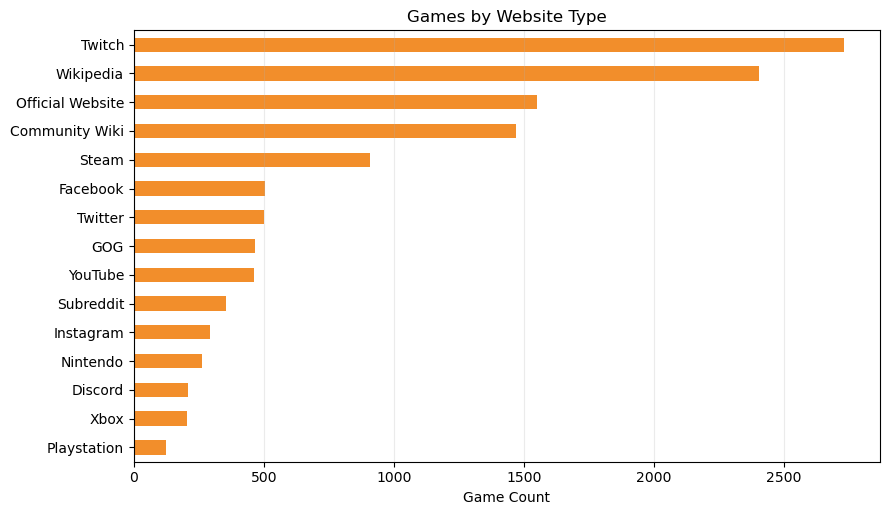

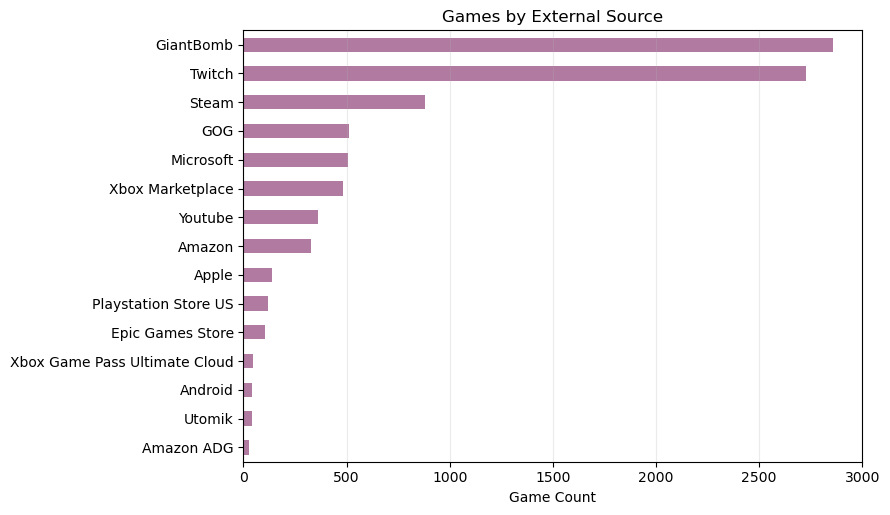

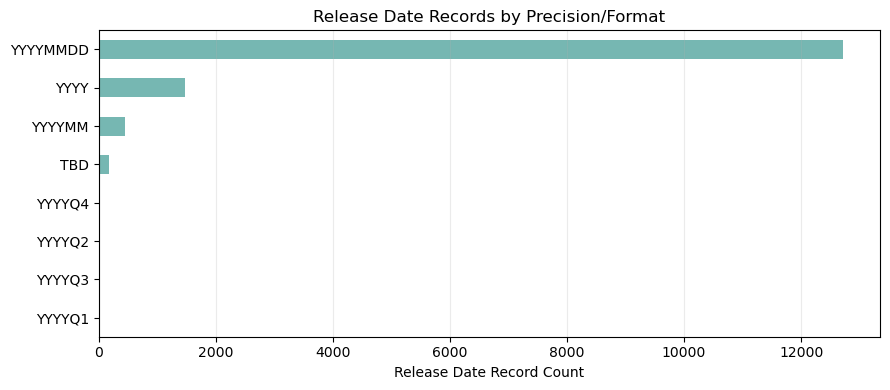

In [23]:
display_section(
    'Catalog Availability and Release Metadata',
    'These tables describe where games have website, external-source, release-date precision, release-status, and region metadata. Counts are descriptive coverage checks, not platform availability claims.'
)

website_type_coverage = run_query('''
WITH total AS (
    SELECT COUNT(DISTINCT game_id) AS total_games
    FROM games
)
SELECT
    COALESCE(wt.type_name, 'Unknown website type') AS website_type,
    COUNT(*) AS website_record_count,
    COUNT(DISTINCT w.game_id) AS game_count,
    total.total_games,
    ROUND(100.0 * COUNT(DISTINCT w.game_id) / total.total_games, 2) AS pct_of_games
FROM websites w
LEFT JOIN website_types wt
    ON w.website_type_id = wt.website_type_id
CROSS JOIN total
GROUP BY COALESCE(wt.type_name, 'Unknown website type'), total.total_games
ORDER BY game_count DESC, website_record_count DESC, website_type;
''')

external_source_coverage = run_query('''
WITH total AS (
    SELECT COUNT(DISTINCT game_id) AS total_games
    FROM games
)
SELECT
    COALESCE(egs.source_name, 'Unknown external source') AS external_source,
    COUNT(*) AS external_game_record_count,
    COUNT(DISTINCT eg.game_id) AS game_count,
    total.total_games,
    ROUND(100.0 * COUNT(DISTINCT eg.game_id) / total.total_games, 2) AS pct_of_games
FROM external_games eg
LEFT JOIN external_game_sources egs
    ON eg.external_game_source_id = egs.external_game_source_id
CROSS JOIN total
GROUP BY COALESCE(egs.source_name, 'Unknown external source'), total.total_games
ORDER BY game_count DESC, external_game_record_count DESC, external_source;
''')

release_date_format_coverage = run_query('''
WITH total AS (
    SELECT COUNT(DISTINCT game_id) AS total_games
    FROM games
)
SELECT
    COALESCE(df.format_name, 'Unknown date format') AS date_format,
    COUNT(*) AS release_date_record_count,
    COUNT(DISTINCT rd.game_id) AS game_count,
    total.total_games,
    ROUND(100.0 * COUNT(DISTINCT rd.game_id) / total.total_games, 2) AS pct_of_games
FROM release_dates rd
LEFT JOIN date_formats df
    ON rd.date_format_id = df.date_format_id
CROSS JOIN total
GROUP BY COALESCE(df.format_name, 'Unknown date format'), total.total_games
ORDER BY release_date_record_count DESC, date_format;
''')

release_date_status_coverage = run_query('''
WITH total AS (
    SELECT COUNT(DISTINCT game_id) AS total_games
    FROM games
)
SELECT
    COALESCE(rds.status_name, 'Unknown release status') AS release_status,
    COUNT(*) AS release_date_record_count,
    COUNT(DISTINCT rd.game_id) AS game_count,
    total.total_games,
    ROUND(100.0 * COUNT(DISTINCT rd.game_id) / total.total_games, 2) AS pct_of_games
FROM release_dates rd
LEFT JOIN release_date_statuses rds
    ON rd.release_date_status_id = rds.release_date_status_id
CROSS JOIN total
GROUP BY COALESCE(rds.status_name, 'Unknown release status'), total.total_games
ORDER BY release_date_record_count DESC, release_status;
''')

release_date_region_coverage = run_query('''
WITH total AS (
    SELECT COUNT(DISTINCT game_id) AS total_games
    FROM games
)
SELECT
    COALESCE(rdr.region_name, 'Unknown release region') AS release_region,
    COUNT(*) AS release_date_record_count,
    COUNT(DISTINCT rd.game_id) AS game_count,
    total.total_games,
    ROUND(100.0 * COUNT(DISTINCT rd.game_id) / total.total_games, 2) AS pct_of_games
FROM release_dates rd
LEFT JOIN release_date_regions rdr
    ON rd.release_date_region_id = rdr.release_date_region_id
CROSS JOIN total
GROUP BY COALESCE(rdr.region_name, 'Unknown release region'), total.total_games
ORDER BY release_date_record_count DESC, release_region;
''')

tables_to_export.update({
    'website_type_coverage': website_type_coverage,
    'external_source_coverage': external_source_coverage,
    'release_date_format_coverage': release_date_format_coverage,
    'release_date_status_coverage': release_date_status_coverage,
    'release_date_region_coverage': release_date_region_coverage,
})

display(website_type_coverage.head(25))
display(external_source_coverage.head(25))
display(release_date_format_coverage)
display(release_date_status_coverage)
display(release_date_region_coverage.head(25))

plot_barh(website_type_coverage, 'website_type', 'game_count', 'Games by Website Type', top_n=15, color='#F28E2B')
plot_barh(external_source_coverage, 'external_source', 'game_count', 'Games by External Source', top_n=15, color='#B07AA1')
plot_barh(release_date_format_coverage, 'date_format', 'release_date_record_count', 'Release Date Records by Precision/Format', top_n=len(release_date_format_coverage), color='#76B7B2')

## Text, Relationship Richness, and Keyword Cleanup

These checks summarize summary/storyline length, relationship-table density, and keyword values that may need cleanup before RAG or dashboard filters.

,count,mean,std,min,25%,50%,75%,max
summary_length,"3,000.00",568.75,425.35,0.00,313.00,495.00,717.25,"9,288.00"
storyline_length,"3,000.00",389.03,"1,006.86",0.00,0.00,0.00,445.25,"20,600.00"


,summary_length_band,game_count
0,Medium summary,1809
1,Long summary,689
2,Short summary,435
3,Missing summary,67


,storyline_length_band,game_count
0,Missing storyline,1930
1,Medium storyline,547
2,Long storyline,432
3,Short storyline,91


,game_id,name,genre_count,theme_count,keyword_count,platform_count,involved_company_count,game_mode_count,player_perspective_count,website_count,external_source_count,screenshot_count,metadata_relationship_count
0,1020,Grand Theft Auto V,3,4,207,5,4,3,2,14,61,18,321
1,15,Fallout 3,2,6,278,3,2,1,2,13,8,5,320
2,282,EverQuest,2,5,279,2,5,2,1,6,3,5,310
3,380,Metal Gear Solid 4: Guns of the Patriots,3,5,258,1,2,1,1,4,2,4,281
4,20,BioShock,4,5,227,3,5,1,1,8,9,5,268
5,59,The Elder Scrolls IV: Oblivion,2,5,228,3,5,1,2,8,7,7,268
6,2943,Scribblenauts Unlimited,4,1,213,5,3,1,1,7,6,12,253
7,74,Mass Effect 2,3,2,208,3,4,1,1,11,8,5,246
8,16,Fallout: New Vegas,2,6,196,3,4,1,2,13,11,7,245
9,686,EverQuest: The Ruins of Kunark,1,3,227,1,1,1,1,3,1,0,239


,metadata_richness_band,game_count,min_relationship_count,median_relationship_count,max_relationship_count
0,Lean relationship profile (<50 links),1805,5,29.00,49
1,Moderate relationship profile (50-99 links),906,50,66.00,99
2,Rich relationship profile (100-149 links),209,100,116.00,149
3,Very rich relationship profile (150+ links),80,150,181.50,321


,keyword_review_category,keyword_count,total_game_mentions
0,Likely semantic term,2711,72932
1,Review platform/store term,1,578
2,Review punctuation or compound term,4,185
3,Review term containing number,171,2859
4,Review very short term,3,55


,keyword_id,keyword_name,keyword_slug,game_count,keyword_review_category
2711,1158,steam,steam,578,Review platform/store term
2712,2452,day/night cycle,day-slash-night-cycle,182,Review punctuation or compound term
2713,14059,best role playing game: nominee - 2016 (the ga...,best-role-playing-game-nominee-2016-the-game-a...,1,Review punctuation or compound term
2714,28782,nintendo 64 peripheral: voice recognition unit...,nintendo-64-peripheral-voice-recognition-unit-vru,1,Review punctuation or compound term
2715,28966,satellaview demo/trial release,satellaview-demo-slash-trial-release,1,Review punctuation or compound term
2716,4359,polygonal 3d,polygonal-3d,708,Review term containing number
2717,4282,60 fps on consoles,60-fps-on-consoles,128,Review term containing number
2718,19,world war ii - ww2,world-war-ii-ww2,115,Review term containing number
2719,13295,xbox 360 backwards compatibility,xbox-360-backwards-compatibility,93,Review term containing number
2720,7403,pax prime 2012,pax-prime-2012,69,Review term containing number


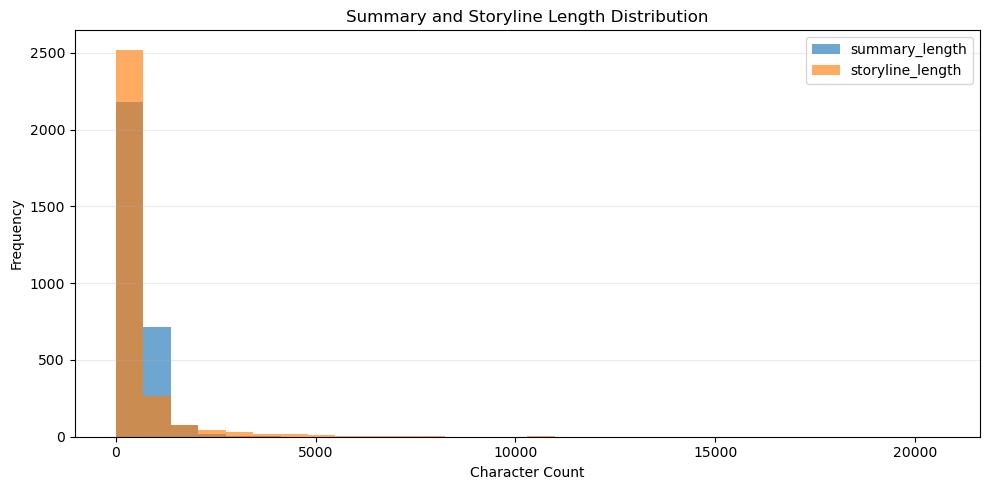

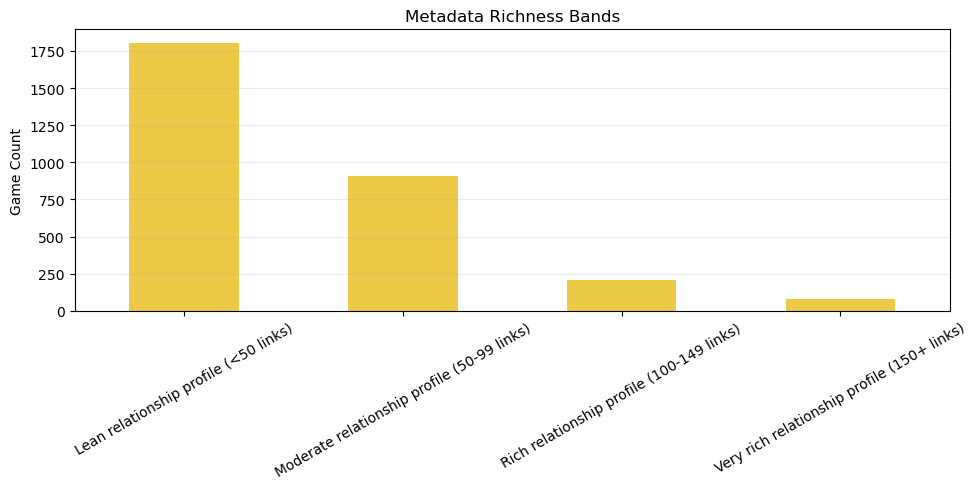

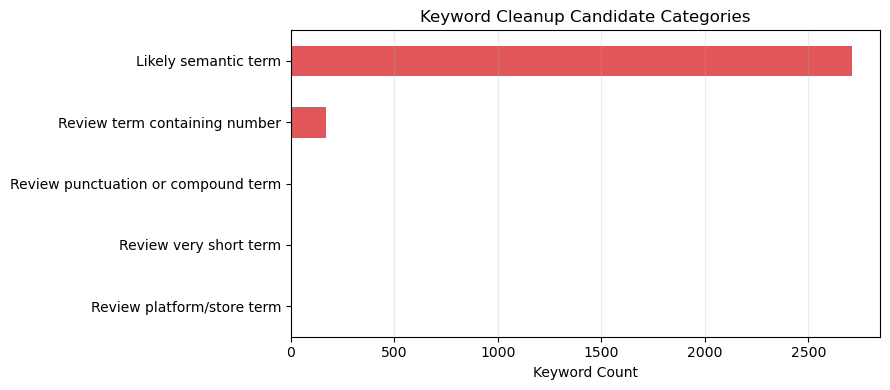

In [24]:
display_section(
    'Text, Relationship Richness, and Keyword Cleanup',
    'These checks summarize summary/storyline length, relationship-table density, and keyword values that may need cleanup before RAG or dashboard filters.'
)

text_length_distribution = run_query('''
SELECT
    game_id,
    name,
    LENGTH(COALESCE(summary, '')) AS summary_length,
    LENGTH(COALESCE(storyline, '')) AS storyline_length,
    CASE
        WHEN summary IS NULL OR TRIM(summary) = '' THEN 'Missing summary'
        WHEN LENGTH(summary) < 250 THEN 'Short summary'
        WHEN LENGTH(summary) < 750 THEN 'Medium summary'
        ELSE 'Long summary'
    END AS summary_length_band,
    CASE
        WHEN storyline IS NULL OR TRIM(storyline) = '' THEN 'Missing storyline'
        WHEN LENGTH(storyline) < 250 THEN 'Short storyline'
        WHEN LENGTH(storyline) < 750 THEN 'Medium storyline'
        ELSE 'Long storyline'
    END AS storyline_length_band
FROM games
ORDER BY summary_length DESC, storyline_length DESC, name;
''')

relationship_counts_per_game = run_query('''
WITH genre_counts AS (
    SELECT game_id, COUNT(*) AS genre_count FROM game_genres GROUP BY game_id
), theme_counts AS (
    SELECT game_id, COUNT(*) AS theme_count FROM game_themes GROUP BY game_id
), keyword_counts AS (
    SELECT game_id, COUNT(*) AS keyword_count FROM game_keywords GROUP BY game_id
), platform_counts AS (
    SELECT game_id, COUNT(*) AS platform_count FROM game_platforms GROUP BY game_id
), company_counts AS (
    SELECT game_id, COUNT(*) AS involved_company_count FROM involved_companies GROUP BY game_id
), mode_counts AS (
    SELECT game_id, COUNT(*) AS game_mode_count FROM game_modes_bridge GROUP BY game_id
), perspective_counts AS (
    SELECT game_id, COUNT(*) AS player_perspective_count FROM game_player_perspectives GROUP BY game_id
), website_counts AS (
    SELECT game_id, COUNT(*) AS website_count FROM websites GROUP BY game_id
), external_counts AS (
    SELECT game_id, COUNT(*) AS external_source_count FROM external_games GROUP BY game_id
), screenshot_counts AS (
    SELECT game_id, COUNT(*) AS screenshot_count FROM screenshots GROUP BY game_id
)
SELECT
    g.game_id,
    g.name,
    COALESCE(gc.genre_count, 0) AS genre_count,
    COALESCE(tc.theme_count, 0) AS theme_count,
    COALESCE(kc.keyword_count, 0) AS keyword_count,
    COALESCE(pc.platform_count, 0) AS platform_count,
    COALESCE(cc.involved_company_count, 0) AS involved_company_count,
    COALESCE(mc.game_mode_count, 0) AS game_mode_count,
    COALESCE(ppc.player_perspective_count, 0) AS player_perspective_count,
    COALESCE(wc.website_count, 0) AS website_count,
    COALESCE(ec.external_source_count, 0) AS external_source_count,
    COALESCE(sc.screenshot_count, 0) AS screenshot_count,
    COALESCE(gc.genre_count, 0) + COALESCE(tc.theme_count, 0) + COALESCE(kc.keyword_count, 0)
        + COALESCE(pc.platform_count, 0) + COALESCE(cc.involved_company_count, 0)
        + COALESCE(mc.game_mode_count, 0) + COALESCE(ppc.player_perspective_count, 0)
        + COALESCE(wc.website_count, 0) + COALESCE(ec.external_source_count, 0)
        + COALESCE(sc.screenshot_count, 0) AS metadata_relationship_count
FROM games g
LEFT JOIN genre_counts gc ON g.game_id = gc.game_id
LEFT JOIN theme_counts tc ON g.game_id = tc.game_id
LEFT JOIN keyword_counts kc ON g.game_id = kc.game_id
LEFT JOIN platform_counts pc ON g.game_id = pc.game_id
LEFT JOIN company_counts cc ON g.game_id = cc.game_id
LEFT JOIN mode_counts mc ON g.game_id = mc.game_id
LEFT JOIN perspective_counts ppc ON g.game_id = ppc.game_id
LEFT JOIN website_counts wc ON g.game_id = wc.game_id
LEFT JOIN external_counts ec ON g.game_id = ec.game_id
LEFT JOIN screenshot_counts sc ON g.game_id = sc.game_id
ORDER BY metadata_relationship_count DESC, g.name;
''')

metadata_richness_by_game = run_query('''
WITH genre_counts AS (
    SELECT game_id, COUNT(*) AS genre_count FROM game_genres GROUP BY game_id
), theme_counts AS (
    SELECT game_id, COUNT(*) AS theme_count FROM game_themes GROUP BY game_id
), keyword_counts AS (
    SELECT game_id, COUNT(*) AS keyword_count FROM game_keywords GROUP BY game_id
), platform_counts AS (
    SELECT game_id, COUNT(*) AS platform_count FROM game_platforms GROUP BY game_id
), company_counts AS (
    SELECT game_id, COUNT(*) AS involved_company_count FROM involved_companies GROUP BY game_id
), mode_counts AS (
    SELECT game_id, COUNT(*) AS game_mode_count FROM game_modes_bridge GROUP BY game_id
), perspective_counts AS (
    SELECT game_id, COUNT(*) AS player_perspective_count FROM game_player_perspectives GROUP BY game_id
), website_counts AS (
    SELECT game_id, COUNT(*) AS website_count FROM websites GROUP BY game_id
), external_counts AS (
    SELECT game_id, COUNT(*) AS external_source_count FROM external_games GROUP BY game_id
), screenshot_counts AS (
    SELECT game_id, COUNT(*) AS screenshot_count FROM screenshots GROUP BY game_id
), time_to_beat_counts AS (
    SELECT game_id, COUNT(*) AS time_to_beat_count FROM game_time_to_beats GROUP BY game_id
)
SELECT
    g.game_id,
    g.name,
    CASE WHEN g.summary IS NOT NULL AND TRIM(g.summary) != '' THEN 1 ELSE 0 END AS has_summary,
    CASE WHEN g.storyline IS NOT NULL AND TRIM(g.storyline) != '' THEN 1 ELSE 0 END AS has_storyline,
    CASE WHEN g.cover_id IS NOT NULL THEN 1 ELSE 0 END AS has_cover_reference,
    CASE WHEN COALESCE(gc.genre_count, 0) > 0 THEN 1 ELSE 0 END AS has_genre,
    CASE WHEN COALESCE(tc.theme_count, 0) > 0 THEN 1 ELSE 0 END AS has_theme,
    CASE WHEN COALESCE(kc.keyword_count, 0) > 0 THEN 1 ELSE 0 END AS has_keyword,
    CASE WHEN COALESCE(pc.platform_count, 0) > 0 THEN 1 ELSE 0 END AS has_platform,
    CASE WHEN COALESCE(cc.involved_company_count, 0) > 0 THEN 1 ELSE 0 END AS has_company,
    CASE WHEN COALESCE(mc.game_mode_count, 0) > 0 THEN 1 ELSE 0 END AS has_game_mode,
    CASE WHEN COALESCE(ppc.player_perspective_count, 0) > 0 THEN 1 ELSE 0 END AS has_player_perspective,
    CASE WHEN COALESCE(wc.website_count, 0) > 0 THEN 1 ELSE 0 END AS has_website,
    CASE WHEN COALESCE(ec.external_source_count, 0) > 0 THEN 1 ELSE 0 END AS has_external_source,
    CASE WHEN COALESCE(sc.screenshot_count, 0) > 0 THEN 1 ELSE 0 END AS has_screenshot,
    CASE WHEN COALESCE(tbc.time_to_beat_count, 0) > 0 THEN 1 ELSE 0 END AS has_time_to_beat
FROM games g
LEFT JOIN genre_counts gc ON g.game_id = gc.game_id
LEFT JOIN theme_counts tc ON g.game_id = tc.game_id
LEFT JOIN keyword_counts kc ON g.game_id = kc.game_id
LEFT JOIN platform_counts pc ON g.game_id = pc.game_id
LEFT JOIN company_counts cc ON g.game_id = cc.game_id
LEFT JOIN mode_counts mc ON g.game_id = mc.game_id
LEFT JOIN perspective_counts ppc ON g.game_id = ppc.game_id
LEFT JOIN website_counts wc ON g.game_id = wc.game_id
LEFT JOIN external_counts ec ON g.game_id = ec.game_id
LEFT JOIN screenshot_counts sc ON g.game_id = sc.game_id
LEFT JOIN time_to_beat_counts tbc ON g.game_id = tbc.game_id;
''')

richness_signal_cols = [col for col in metadata_richness_by_game.columns if col.startswith('has_')]
metadata_richness_by_game['metadata_signal_score'] = metadata_richness_by_game[richness_signal_cols].sum(axis=1)
metadata_richness_by_game = metadata_richness_by_game.merge(
    relationship_counts_per_game[['game_id', 'metadata_relationship_count']],
    on='game_id',
    how='left',
)
metadata_richness_by_game['metadata_relationship_count'] = metadata_richness_by_game['metadata_relationship_count'].fillna(0).astype(int)

def metadata_richness_band(relationship_count):
    if relationship_count < 50:
        return 'Lean relationship profile (<50 links)'
    if relationship_count < 100:
        return 'Moderate relationship profile (50-99 links)'
    if relationship_count < 150:
        return 'Rich relationship profile (100-149 links)'
    return 'Very rich relationship profile (150+ links)'

metadata_richness_by_game['metadata_richness_score'] = metadata_richness_by_game['metadata_relationship_count']
metadata_richness_by_game['metadata_richness_band'] = metadata_richness_by_game['metadata_relationship_count'].apply(metadata_richness_band)
metadata_band_order = [
    'Lean relationship profile (<50 links)',
    'Moderate relationship profile (50-99 links)',
    'Rich relationship profile (100-149 links)',
    'Very rich relationship profile (150+ links)',
]
metadata_richness_bands = (
    metadata_richness_by_game
    .groupby('metadata_richness_band', as_index=False)
    .agg(
        game_count=('game_id', 'nunique'),
        min_relationship_count=('metadata_relationship_count', 'min'),
        median_relationship_count=('metadata_relationship_count', 'median'),
        max_relationship_count=('metadata_relationship_count', 'max'),
    )
)
metadata_richness_bands['median_relationship_count'] = metadata_richness_bands['median_relationship_count'].round(2)
metadata_richness_bands['band_order'] = metadata_richness_bands['metadata_richness_band'].map({band: i for i, band in enumerate(metadata_band_order, start=1)})
metadata_richness_bands = metadata_richness_bands.sort_values('band_order')

keyword_cleanup_candidates = run_query('''
SELECT
    kw.keyword_id,
    kw.name AS keyword_name,
    kw.slug AS keyword_slug,
    COUNT(DISTINCT gk.game_id) AS game_count,
    CASE
        WHEN LENGTH(TRIM(kw.name)) <= 2 THEN 'Review very short term'
        WHEN LOWER(kw.name) IN ('steam', 'playstation', 'xbox', 'windows', 'linux', 'mac', 'nintendo', 'switch', 'pc') THEN 'Review platform/store term'
        WHEN kw.name LIKE '%,%' OR kw.name LIKE '%/%' OR kw.name LIKE '%:%' THEN 'Review punctuation or compound term'
        WHEN kw.name GLOB '*[0-9]*' THEN 'Review term containing number'
        ELSE 'Likely semantic term'
    END AS keyword_review_category
FROM game_keywords gk
JOIN keywords kw
    ON gk.keyword_id = kw.keyword_id
GROUP BY kw.keyword_id, kw.name, kw.slug
ORDER BY keyword_review_category, game_count DESC, keyword_name;
''')

keyword_cleanup_summary = (
    keyword_cleanup_candidates
    .groupby('keyword_review_category', as_index=False)
    .agg(keyword_count=('keyword_name', 'count'), total_game_mentions=('game_count', 'sum'))
    .sort_values(['keyword_review_category'])
)

tables_to_export.update({
    'text_length_distribution': text_length_distribution,
    'relationship_counts_per_game': relationship_counts_per_game,
    'metadata_richness_by_game': metadata_richness_by_game,
    'metadata_richness_bands': metadata_richness_bands.drop(columns=['band_order'], errors='ignore'),
    'keyword_cleanup_candidates': keyword_cleanup_candidates,
    'keyword_cleanup_summary': keyword_cleanup_summary,
})

display(text_length_distribution[['summary_length', 'storyline_length']].describe().T)
display(text_length_distribution['summary_length_band'].value_counts().rename_axis('summary_length_band').reset_index(name='game_count'))
display(text_length_distribution['storyline_length_band'].value_counts().rename_axis('storyline_length_band').reset_index(name='game_count'))
display(relationship_counts_per_game.head(20))
display(metadata_richness_bands.drop(columns=['band_order'], errors='ignore'))
display(keyword_cleanup_summary)
display(keyword_cleanup_candidates[keyword_cleanup_candidates['keyword_review_category'] != 'Likely semantic term'].head(50))

if not text_length_distribution.empty:
    ax = text_length_distribution[['summary_length', 'storyline_length']].plot.hist(bins=30, alpha=0.65, figsize=(10, 5))
    ax.set_title('Summary and Storyline Length Distribution')
    ax.set_xlabel('Character Count')
    ax.grid(axis='y', alpha=0.25)
    plt.tight_layout()
    plt.show()

plot_bar(metadata_richness_bands, 'metadata_richness_band', 'game_count', 'Metadata Richness Bands', color='#EDC948', rotation=30)
plot_barh(keyword_cleanup_summary, 'keyword_review_category', 'keyword_count', 'Keyword Cleanup Candidate Categories', top_n=len(keyword_cleanup_summary), color='#E15759')

## Media Readiness

These tables describe cover and screenshot availability for dashboards, reports, and later application UI work.

,metric,game_count,total_games,pct_of_games
0,Games with cover,2994,3000,99.80
1,Games with screenshot,2781,3000,92.70
2,Games with cover and screenshot,2781,3000,92.70
3,Games with no cover or screenshot,6,3000,0.20


,screenshot_count_band,game_count
0,0 screenshots,219
1,1 screenshot,111
2,2-3 screenshots,422
3,4-6 screenshots,1360
4,7+ screenshots,888


,image_type,image_record_count,records_with_dimensions,records_with_url,pct_with_dimensions,pct_with_url
0,Cover,2994,2994,2994,100.00,100.00
1,Screenshot,17364,17363,17364,99.99,100.00


,game_id,name,cover_count,covers_with_dimensions,covers_with_url,screenshot_count,screenshots_with_dimensions,screenshots_with_url
0,600,Apache,1,1,1,31,31,31
1,2512,Realms of Arkania: Star Trail,1,1,1,24,24,24
2,586,Abuse,1,1,1,20,20,20
3,2305,Amazon,1,1,1,20,20,20
4,622,Call of Duty 2,1,1,1,20,20,20
5,3007,Dynasty Warriors 4,1,1,1,20,20,20
6,1252,"Gabriel Knight 3: Blood of the Sacred, Blood o...",1,1,1,20,20,20
7,2490,Man Enough,1,1,1,20,20,20
8,1407,Metal Slug 2,1,1,1,20,20,20
9,236,Myst,1,1,1,20,20,20


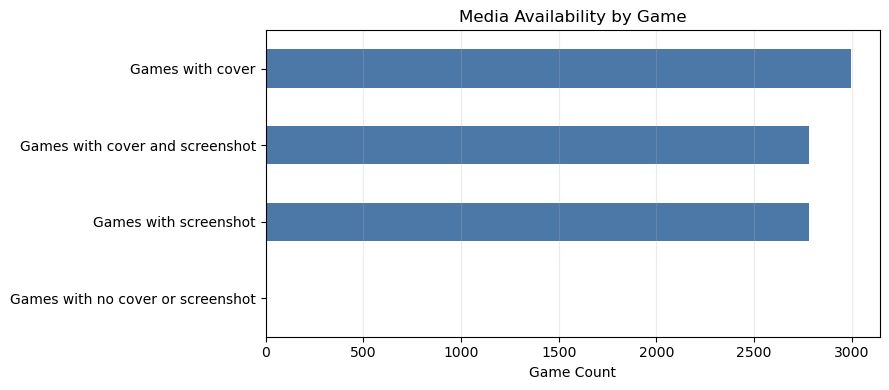

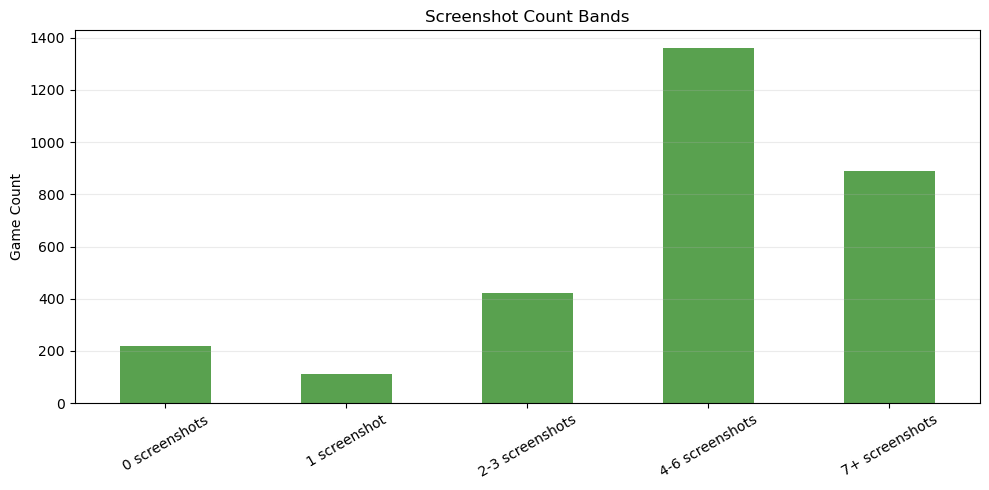

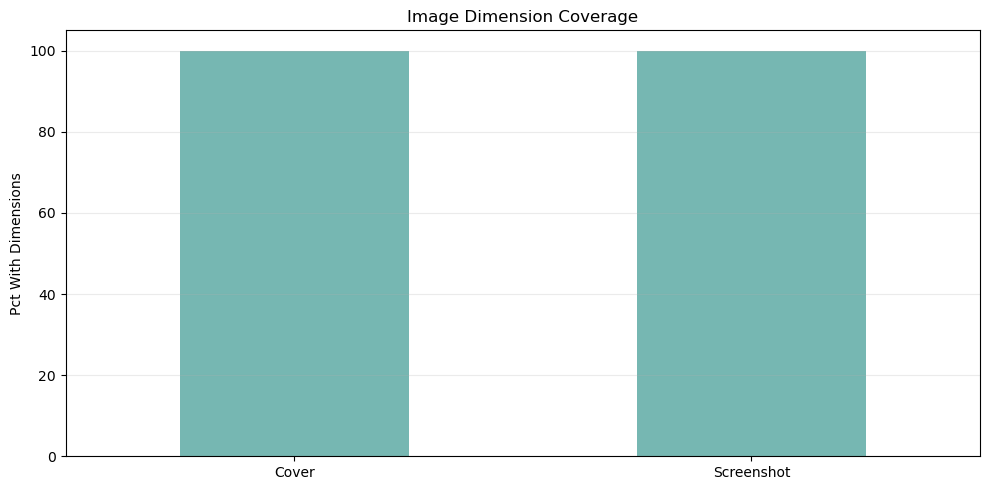

In [25]:
display_section(
    'Media Readiness',
    'These tables describe cover and screenshot availability for dashboards, reports, and later application UI work.'
)

media_by_game = run_query('''
WITH cover_counts AS (
    SELECT
        game_id,
        COUNT(*) AS cover_count,
        SUM(CASE WHEN width IS NOT NULL AND height IS NOT NULL THEN 1 ELSE 0 END) AS covers_with_dimensions,
        SUM(CASE WHEN url IS NOT NULL AND TRIM(url) != '' THEN 1 ELSE 0 END) AS covers_with_url
    FROM covers
    GROUP BY game_id
), screenshot_counts AS (
    SELECT
        game_id,
        COUNT(*) AS screenshot_count,
        SUM(CASE WHEN width IS NOT NULL AND height IS NOT NULL THEN 1 ELSE 0 END) AS screenshots_with_dimensions,
        SUM(CASE WHEN url IS NOT NULL AND TRIM(url) != '' THEN 1 ELSE 0 END) AS screenshots_with_url
    FROM screenshots
    GROUP BY game_id
)
SELECT
    g.game_id,
    g.name,
    COALESCE(cc.cover_count, 0) AS cover_count,
    COALESCE(cc.covers_with_dimensions, 0) AS covers_with_dimensions,
    COALESCE(cc.covers_with_url, 0) AS covers_with_url,
    COALESCE(sc.screenshot_count, 0) AS screenshot_count,
    COALESCE(sc.screenshots_with_dimensions, 0) AS screenshots_with_dimensions,
    COALESCE(sc.screenshots_with_url, 0) AS screenshots_with_url
FROM games g
LEFT JOIN cover_counts cc ON g.game_id = cc.game_id
LEFT JOIN screenshot_counts sc ON g.game_id = sc.game_id
ORDER BY screenshot_count DESC, cover_count DESC, g.name;
''')

total_games_for_media = int(kpi_snapshot.loc[kpi_snapshot['kpi'] == 'Total Games', 'value'].iloc[0])
media_availability_summary = pd.DataFrame([
    {'metric': 'Games with cover', 'game_count': int((media_by_game['cover_count'] > 0).sum())},
    {'metric': 'Games with screenshot', 'game_count': int((media_by_game['screenshot_count'] > 0).sum())},
    {'metric': 'Games with cover and screenshot', 'game_count': int(((media_by_game['cover_count'] > 0) & (media_by_game['screenshot_count'] > 0)).sum())},
    {'metric': 'Games with no cover or screenshot', 'game_count': int(((media_by_game['cover_count'] == 0) & (media_by_game['screenshot_count'] == 0)).sum())},
])
media_availability_summary['total_games'] = total_games_for_media
media_availability_summary['pct_of_games'] = (100 * media_availability_summary['game_count'] / total_games_for_media).round(2)

def screenshot_count_band(count):
    if count == 0:
        return '0 screenshots'
    if count == 1:
        return '1 screenshot'
    if count <= 3:
        return '2-3 screenshots'
    if count <= 6:
        return '4-6 screenshots'
    return '7+ screenshots'

screenshot_count_order = {
    '0 screenshots': 1,
    '1 screenshot': 2,
    '2-3 screenshots': 3,
    '4-6 screenshots': 4,
    '7+ screenshots': 5,
}
screenshot_count_distribution = media_by_game.copy()
screenshot_count_distribution['screenshot_count_band'] = screenshot_count_distribution['screenshot_count'].apply(screenshot_count_band)
screenshot_count_distribution = (
    screenshot_count_distribution
    .groupby('screenshot_count_band', as_index=False)
    .size()
    .rename(columns={'size': 'game_count'})
)
screenshot_count_distribution['sort_order'] = screenshot_count_distribution['screenshot_count_band'].map(screenshot_count_order)
screenshot_count_distribution = screenshot_count_distribution.sort_values('sort_order')

cover_records = int(media_by_game['cover_count'].sum())
screenshot_records = int(media_by_game['screenshot_count'].sum())
image_dimension_coverage = pd.DataFrame([
    {
        'image_type': 'Cover',
        'image_record_count': cover_records,
        'records_with_dimensions': int(media_by_game['covers_with_dimensions'].sum()),
        'records_with_url': int(media_by_game['covers_with_url'].sum()),
    },
    {
        'image_type': 'Screenshot',
        'image_record_count': screenshot_records,
        'records_with_dimensions': int(media_by_game['screenshots_with_dimensions'].sum()),
        'records_with_url': int(media_by_game['screenshots_with_url'].sum()),
    },
])
image_dimension_coverage['pct_with_dimensions'] = image_dimension_coverage.apply(
    lambda row: round(100 * row['records_with_dimensions'] / row['image_record_count'], 2) if row['image_record_count'] else 0,
    axis=1,
)
image_dimension_coverage['pct_with_url'] = image_dimension_coverage.apply(
    lambda row: round(100 * row['records_with_url'] / row['image_record_count'], 2) if row['image_record_count'] else 0,
    axis=1,
)

tables_to_export.update({
    'media_by_game': media_by_game,
    'media_availability_summary': media_availability_summary,
    'screenshot_count_distribution': screenshot_count_distribution.drop(columns=['sort_order'], errors='ignore'),
    'image_dimension_coverage': image_dimension_coverage,
})

display(media_availability_summary)
display(screenshot_count_distribution.drop(columns=['sort_order'], errors='ignore'))
display(image_dimension_coverage)
display(media_by_game.head(20))

plot_barh(media_availability_summary, 'metric', 'game_count', 'Media Availability by Game', top_n=len(media_availability_summary), color='#4C78A8')
plot_bar(screenshot_count_distribution, 'screenshot_count_band', 'game_count', 'Screenshot Count Bands', color='#59A14F', rotation=30)
plot_bar(image_dimension_coverage, 'image_type', 'pct_with_dimensions', 'Image Dimension Coverage', color='#76B7B2', rotation=0)

# 10. Auto-Generated Takeaway Prompts

Run the next cell after executing the notebook. Use the generated prompts as a starting point for dashboard annotations or report text, then revise them based on the actual charts.

In [26]:
total_games_value = int(kpi_snapshot.loc[kpi_snapshot['kpi'] == 'Total Games', 'value'].iloc[0])
top_genre_text = top_genres.iloc[0]['genre_name'] if not top_genres.empty else 'N/A'
top_platform_text = top_platforms.iloc[0]['platform_name'] if not top_platforms.empty else 'N/A'
rating_coverage_value = kpi_snapshot.loc[kpi_snapshot['kpi'] == 'Games With Total Rating', 'pct_of_games'].iloc[0]
summary_coverage_value = kpi_snapshot.loc[kpi_snapshot['kpi'] == 'Games With Summaries', 'pct_of_games'].iloc[0]
top_perspective_text = player_perspective_distribution.iloc[0]['player_perspective'] if 'player_perspective_distribution' in globals() and not player_perspective_distribution.empty else 'N/A'
time_to_beat_coverage_value = time_to_beat_coverage.loc[time_to_beat_coverage['metric'] == 'Games with time-to-beat record', 'pct_of_games'].iloc[0] if 'time_to_beat_coverage' in globals() and not time_to_beat_coverage.empty else 'N/A'
cover_coverage_value = media_availability_summary.loc[media_availability_summary['metric'] == 'Games with cover', 'pct_of_games'].iloc[0] if 'media_availability_summary' in globals() and not media_availability_summary.empty else 'N/A'
top_metadata_band_text = metadata_richness_bands.sort_values('game_count', ascending=False).iloc[0]['metadata_richness_band'] if 'metadata_richness_bands' in globals() and not metadata_richness_bands.empty else 'N/A'

def format_pct(value):
    try:
        return f'{float(value):.2f}%'
    except (TypeError, ValueError):
        return 'N/A'

takeaway_text = f'''
- The current project sample contains **{total_games_value:,} games**.
- The most represented genre in this sample is **{top_genre_text}**.
- The most represented platform in this sample is **{top_platform_text}**.
- The most represented player perspective is **{top_perspective_text}**.
- **{format_pct(rating_coverage_value)}** of games have `total_rating` available in this sample.
- **{format_pct(summary_coverage_value)}** of games have summary text available in this sample.
- **{format_pct(time_to_beat_coverage_value)}** of games have time-to-beat records in this sample.
- **{format_pct(cover_coverage_value)}** of games have cover records in this sample.
- The largest relationship-count richness band is **{top_metadata_band_text}**.
- These takeaways describe the extracted project sample only, not the full IGDB catalog.
'''

display(Markdown(takeaway_text))


- The current project sample contains **3,000 games**.
- The most represented genre in this sample is **Adventure**.
- The most represented platform in this sample is **PC (Microsoft Windows)**.
- The most represented player perspective is **Third person**.
- **86.77%** of games have `total_rating` available in this sample.
- **97.77%** of games have summary text available in this sample.
- **35.30%** of games have time-to-beat records in this sample.
- **99.80%** of games have cover records in this sample.
- The largest relationship-count richness band is **Lean relationship profile (<50 links)**.
- These takeaways describe the extracted project sample only, not the full IGDB catalog.


# Additional Descriptive Areas Covered

The notebook now covers the expanded descriptive areas from the plan, while staying inside the descriptive pillar:

## Gameplay and Experience

- Game modes and multiplayer support.
- Player perspectives such as first-person, third-person, side view, and bird view.
- Time-to-beat coverage and normal playtime bands for available records.

## Catalog and Availability

- Website type coverage.
- External game source coverage.
- Release-date precision, release-status, and release-region coverage.

## Metadata and RAG Readiness

- Summary/storyline length distributions.
- Number of genres, themes, keywords, platforms, and companies per game.
- Relationship-count richness bands for sparse versus rich game profiles.
- Keyword cleanup candidate categories.

## Media and Presentation

- Games with covers and screenshots.
- Screenshot count per game.
- Image dimension coverage for UI consistency.

## Scope Guardrail

Avoid turning this descriptive notebook into diagnostic analysis. Questions like which genres perform best, why ratings differ, hidden-gem identification, or what games to recommend should stay in later pillars.

# 11. Optional Export

This cell exports the notebook's descriptive result tables to `data/analytics/descriptive/`. These CSVs can later feed a final Python script or Streamlit dashboard.

In [27]:
EXPORT_TABLES = True

if EXPORT_TABLES:
    exported_files = []
    for table_name, df in tables_to_export.items():
        output_path = OUTPUT_DIR / f'{table_name}.csv'
        df.to_csv(output_path, index=False)
        exported_files.append(str(output_path.relative_to(ROOT_DIR)))
    display(pd.DataFrame({'exported_file': exported_files}))
else:
    print('CSV export skipped. Set EXPORT_TABLES = True to export descriptive outputs.')

,exported_file
0,data\analytics\descriptive\database_table_row_...
1,data\analytics\descriptive\database_status.csv
2,data\analytics\descriptive\kpi_snapshot.csv
3,data\analytics\descriptive\top_genres.csv
4,data\analytics\descriptive\top_themes.csv
5,data\analytics\descriptive\top_keywords.csv
6,data\analytics\descriptive\game_type_breakdown...
7,data\analytics\descriptive\game_status_breakdo...
8,data\analytics\descriptive\top_platforms.csv
9,data\analytics\descriptive\platform_family_dis...


# 12. Close Database Connection

Run this at the end of the notebook session.

In [28]:
conn.close()
print('Database connection closed.')

Database connection closed.
